In [ ]:
!pip install git+https://github.com/fangwei123456/spikingjelly.git


  Cloning https://github.com/fangwei123456/spikingjelly.git to /tmp/pip-req-build-fv_gvzh1
  Running command git clone --filter=blob:none --quiet https://github.com/fangwei123456/spikingjelly.git /tmp/pip-req-build-fv_gvzh1
  Resolved https://github.com/fangwei123456/spikingjelly.git to commit 910ed82b9a3e15b5a83f71122251f70f09ac3a1a
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for spikingjelly: filename=spikingjelly-0.0.0.0.15-py3-none-any.whl size=489180 sha256=c868b82156573ef870a68b2df80e2ad640d018f16e84054dc149c2b383eb56ea
  Stored in directory: /tmp/pip-ephem-wheel-cache-4gh73y4o/wheels/93/ab/c9/e0318e4c9feaebc1632bcc0168638a2ed5ef17340741c9ad49
Successfully built spikingjelly


# Get paired spikes C100

In [ ]:
import torch
import torch.nn as nn
import datetime
from tqdm import tqdm
import torch.nn.functional as F
import torchvision
import torchvision.datasets as dset
from torchvision import transforms
from PIL.Image import BILINEAR
from torch.utils.data import Dataset, DataLoader

from spikingjelly.activation_based import functional, layer, surrogate, neuron, monitor#, accelerating
from spikingjelly.activation_based.neuron import ParametricLIFNode as PLIFNode
from spikingjelly.activation_based.neuron import LIFNode
import numpy as np
import pandas as pd
import os
import h5py
import argparse
import time
import sys
import glob
import re
import matplotlib.pyplot as plt

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys
sys.path.append('/content/drive/MyDrive/FORTH/Colab Codes')
from helpers import log_tau_after_epoch
from spiking_resnet_archs import *

In [ ]:
def load_checkpoint(net, checkpoint_path, device):

    checkpoint = torch.load(checkpoint_path, map_location=device)

    net.load_state_dict(checkpoint['net'])
    # optimizer.load_state_dict(checkpoint['optimizer'])
    # scheduler.load_state_dict(checkpoint['lr_scheduler'])

    end_epoch = checkpoint['epoch']
    max_test_acc = checkpoint['max_test_acc']

    return net, end_epoch, max_test_acc

In [ ]:

class ShufflePixelsHW:
    def __init__(self, frac=0.1):
        self.frac = frac

    def __call__(self, x):
        # x: (C, H, W)
        C, H, W = x.shape
        N = H * W
        k = int(self.frac * N)

        # flatten spatial dims
        x_flat = x.view(C, -1)

        idx = torch.randperm(N)
        sel = idx[:k]
        perm = sel[torch.randperm(k)]

        # apply same permutation to all channels
        x_flat[:, sel] = x_flat[:, perm]

        return x_flat.view(C, H, W)


In [ ]:
cifar100_dir = '/content/drive/MyDrive/FORTH/Colab Codes/CIFAR10'


data_transformers = {

    'rotS': transforms.Compose([
            transforms.RandomRotation(degrees=(20, 40), interpolation=BILINEAR, expand=False, fill=None),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
        ]),
    'rotM': transforms.Compose([
            transforms.RandomRotation(degrees=(60, 80), interpolation=BILINEAR, expand=False, fill=None),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
        ]),
    'rotL': transforms.Compose([
            transforms.RandomRotation(degrees=(110, 130), interpolation=BILINEAR, expand=False, fill=None),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
        ]),



    'blurS': transforms.Compose([
            transforms.GaussianBlur(kernel_size=(3, 3), sigma=(0.5)),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
        ]),
    'blurM': transforms.Compose([
            transforms.GaussianBlur(kernel_size=(5, 5), sigma=(1.0)),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
        ]),
    'blurL': transforms.Compose([
            transforms.GaussianBlur(kernel_size=(7, 7), sigma=(1.5)),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
        ]),
    'blurSShuf': transforms.Compose([
            transforms.GaussianBlur(kernel_size=(3, 3), sigma=(0.5)),
            ShufflePixelsHW(frac=0.1),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
        ]),
    'blurMShuf': transforms.Compose([
            transforms.GaussianBlur(kernel_size=(5, 5), sigma=(1.0)),
            ShufflePixelsHW(frac=0.1),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
        ]),
    'blurLShuf': transforms.Compose([
            transforms.GaussianBlur(kernel_size=(7, 7), sigma=(1.5)),
            ShufflePixelsHW(frac=0.1),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
        ]),

    'cropS': transforms.Compose([
            transforms.RandomResizedCrop(32, scale = (0.6, 0.8)),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
        ]),
    'cropM': transforms.Compose([
            transforms.RandomResizedCrop(32, scale = (0.4, 0.6)),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
        ]),
    'cropL': transforms.Compose([
            transforms.RandomResizedCrop(32, scale = (0.2, 0.4)),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
        ]),


    'test':
        # transforms.RandomHorizontalFlip(p = 0.0001)
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))


}

In [ ]:
base_dataset = torchvision.datasets.CIFAR10(
    root=cifar100_dir,
    train=False,
    transform=transforms.ToTensor(),
    download=False
)

In [ ]:
class TransformDataset(Dataset):
    def __init__(self, base_dataset, transform_key, data_transformers):
        self.base_dataset = base_dataset
        self.test_transform = data_transformers['test']
        if np.asarray(transform_key).size > 1:
            self.transform = [data_transformers[tkey] for tkey in transform_key]
            self.names = [tkey for tkey in transform_key]
            self.many = True
        else:
            self.transform = data_transformers[transform_key]
            self.names = [transform_key]
            self.many = False

        self.mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
        self.std = torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1)

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        img, label = self.base_dataset[idx]

        img_test = self.test_transform(img)

        if self.many:
            outs = []
            for trans in self.transform:
                outs.append(trans(img))
            outs.append(img_test)
        else:
            img_transformed = self.transform(img)
            outs = [img_transformed, img_test]

        # noise = torch.rand(1, 32, 32)
        # noise = noise.repeat(3, 1, 1)
        # noise = (noise - self.mean) / self.std

        # outs.append(noise)


        # gray_val = 0.5
        # noise = torch.randn(3, 32, 32) * 0.05 + gray_val  # mean 0.5, std 0.05
        # noise = (noise - self.mean) / self.std
        # outs.append(noise)

        return tuple(outs), label

In [ ]:
data_transformers.keys()

dict_keys(['rotS', 'rotM', 'rotL', 'blurS', 'blurM', 'blurL', 'blurSShuf', 'blurMShuf', 'blurLShuf', 'cropS', 'cropM', 'cropL', 'test'])

### Plot + Corrs

In [ ]:
batch_size = 3000

In [ ]:
dataset = TransformDataset(base_dataset, ['rotS', 'rotM', 'rotL', 'blurS', 'blurM', 'blurL', 'cropS', 'cropM', 'cropL'], data_transformers)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [ ]:
imgs, labels = next(iter(loader))

In [ ]:
ix = 0

32


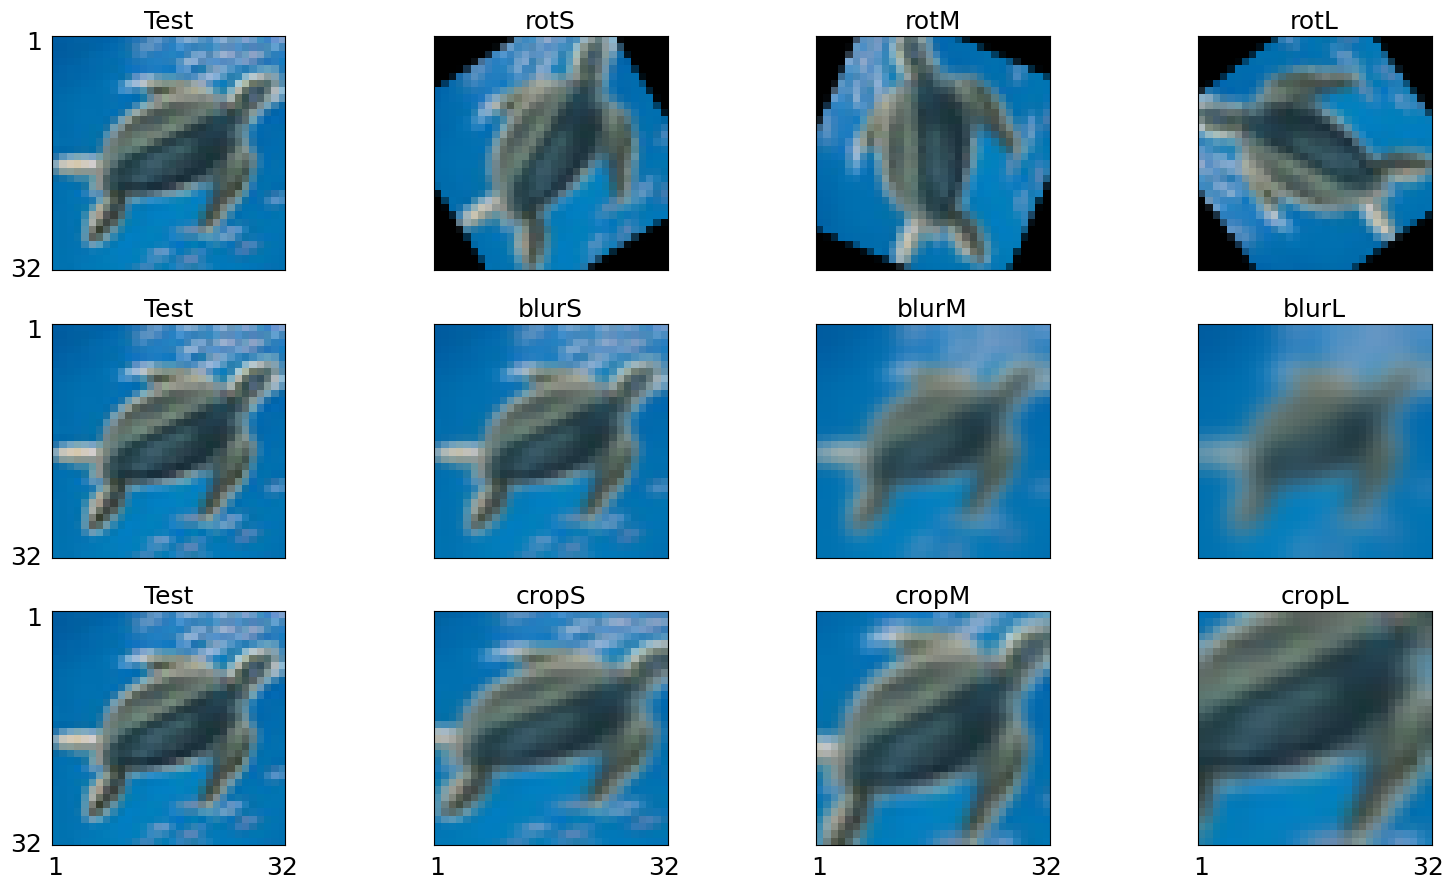

In [ ]:
fig, axs = plt.subplots(3,4, figsize=(16,9), sharex=True, sharey=True)
ix += 1
for name, img_b, ax in zip(dataset.names, imgs, axs[:, 1:].ravel()):
    ax.imshow(img_b[ix].permute(1,2,0))
    ax.set_title(name, fontsize=18)
    ax.set_xticks([0, 31])
    ax.set_yticks([0, 31])
    ax.set_yticklabels([1, 32], fontsize=18)
    ax.set_xticklabels([1, 32], fontsize=18)
    ax.tick_params(axis='both', width=0)
for ax in axs[:, 0]:
    ax.imshow(imgs[9][ix].permute(1,2,0))
    ax.set_title('Test', fontsize=18)
    ax.set_xticks([0, 31])
    ax.set_yticks([0, 31])
    ax.set_yticklabels([1, 32], fontsize=18)
    ax.set_xticklabels([1, 32], fontsize=18)
    ax.tick_params(axis='both', width=0)
    # break
print(ix)
fig.tight_layout()
fig.show()

In [ ]:
input_names = dataset.names + ['Task', 'Noise', 'Grey']

In [ ]:
# Flatten and move to device
device = 'cuda:1'
def flatten_images(mats):
    return torch.tensor(mats).view(mats.shape[0], -1).to(device)

def correlation_matrix(x, y):
    x_norm = x / x.norm(dim=1, keepdim=True)
    y_norm = y / y.norm(dim=1, keepdim=True)
    return torch.mm(x_norm, y_norm.t())  # shape: (len(x), len(y))


corrs = {}

task_flat = flatten_images(imgs[9])
task_flat = task_flat - task_flat.mean(dim=1, keepdim=True)
for ikx, key, img in zip(np.arange(12), input_names, imgs):
    if key == 'Task':
        print(ikx, '!!')
        continue

    print(ikx)
    typeA_flat = flatten_images(img)
    typeA_flat = typeA_flat - typeA_flat.mean(dim=1, keepdim=True)
    corrs[key] = correlation_matrix(task_flat, typeA_flat)






/tmp/ipykernel_42462/863126147.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(mats).view(mats.shape[0], -1).to(device)


0
1
2
3
4
5
6
7
8
9 !!
10
11


In [ ]:
means = []
stds = []
for key, val in corrs.items():
    print(key, torch.diagonal(val).mean(), torch.diagonal(val).std())
    means.append(torch.diagonal(val).mean().cpu().numpy())
    stds.append(torch.diagonal(val).std().cpu().numpy())

rotS tensor(0.3136, device='cuda:1') tensor(0.2118, device='cuda:1')
rotM tensor(0.1466, device='cuda:1') tensor(0.2067, device='cuda:1')
rotL tensor(0.0364, device='cuda:1') tensor(0.2263, device='cuda:1')
blurS tensor(0.9962, device='cuda:1') tensor(0.0023, device='cuda:1')
blurM tensor(0.9656, device='cuda:1') tensor(0.0213, device='cuda:1')
blurL tensor(0.9340, device='cuda:1') tensor(0.0382, device='cuda:1')
cropS tensor(0.6642, device='cuda:1') tensor(0.1740, device='cuda:1')
cropM tensor(0.4878, device='cuda:1') tensor(0.2101, device='cuda:1')
cropL tensor(0.3470, device='cuda:1') tensor(0.2456, device='cuda:1')
Noise tensor(-0.0032, device='cuda:1') tensor(0.0336, device='cuda:1')
Grey tensor(-0.0132, device='cuda:1') tensor(0.0981, device='cuda:1')


In [ ]:
p

###  Spike outs

In [ ]:
paths = glob.glob('/content/drive/MyDrive/FORTH/Colab Codes/models/C10_T8_*KS32_FullSNN_Small*/checkpoint_max*')
paths


['/content/drive/MyDrive/FORTH/Colab Codes/models/C10_T8_[KS32_FullSNN_Small]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/checkpoint_max.pth']

In [ ]:
# net = sew_resnet18(cnf = 'ADD', spiking_neuron=PLIFNode).to(device)
device = 'cpu'
step_mode = 'm'
init_tau = 2.0
detach_reset = True
class_num = 10
cnf = 'ADD'
surrogate_function = surrogate.ATan()
bn_momentum = 0.1
T = 8

# net = sew_resnet18(cnf = 'ADD', spiking_neuron=PLIFNode).to(device)
net = KS32_FullySpiking_Small(BasicBlock, [1,1,1], num_classes = class_num, bn_momentum=bn_momentum,
                        cnf=cnf , spiking_neuron=PLIFNode, init_tau=init_tau, detach_reset=detach_reset, surrogate_function=surrogate_function).to(device)
functional.set_step_mode(net, step_mode=step_mode)


In [ ]:
# path = glob.glob(r'./models/C100_T[4]_[GD]_PLIF[SEWResNet_2222_mp]_bn[0.9]_tau[2.0]_batch[200]_cnf[ADD]/checkpoint*max.pth')[0]
# path = r'./models/C100_T[4]_[GD]_PLIF[SEWResNet_2222_mp]_bn[0.9]_tau[2.0]_batch[200]_cnf[ADD]/checkpoint_max.pth'
path = paths[0]
net, end_epoch, max_test_acc = load_checkpoint(net, path, device)



In [ ]:
max_test_acc, end_epoch

(0.7487000338733196, 44)

In [ ]:
def cal_firing_rate(s_seq: torch.Tensor):
    return s_seq.mean()

In [ ]:
def reshape_spikes(xx:torch.Tensor):
    T, B = xx.shape[:2]
    yy = xx.permute(*range(2, xx.dim()), 1, 0).reshape(-1, T * B)
    return yy.cpu()

In [ ]:
# fr_monitor = monitor.OutputMonitor(net, PLIFNode, cal_firing_rate)
spike_seq_monitor = monitor.OutputMonitor(net, PLIFNode, reshape_spikes)

In [ ]:
import gc
gc.collect()
# torch.cuda.empty_cache()
# torch.cuda.ipc_collect()

141

In [ ]:
250*10*8

20000

In [ ]:
from torch.utils.data import DataLoader, SubsetRandomSampler
import torch

N = len(base_dataset)
perm = torch.randperm(N)          # random order, but explicit
sampler = SubsetRandomSampler(perm)

dataset = TransformDataset(base_dataset, ['blurS', 'blurM', 'blurL', 'blurSShuf', 'blurMShuf', 'blurLShuf'], data_transformers)
loader = DataLoader(
    dataset,
    batch_size=250,
    sampler=sampler
)

In [ ]:
batch_size = 500
dataset = TransformDataset(base_dataset, ['blurS', 'blurM', 'blurL'], data_transformers)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [ ]:
input_names = dataset.names + ['Test']

In [ ]:
torch.save(perm, os.path.join(os.path.dirname(path), "sample_order.pt"))


In [ ]:
# imgs, labels = next(iter(loader))

In [ ]:
batched = []
for imgs, labels in loader:
    batched.append([imgs, labels])

In [ ]:
len(batched[0]), len(batched[0][0]), len(batched[0][0][0]), len(batched[0][1]), batched[0][1].shape

(2, 7, 250, 250, torch.Size([250]))

In [ ]:
input_names

['blurS', 'blurM', 'blurL', 'blurSShuf', 'blurMShuf', 'blurLShuf', 'Test']

In [ ]:
# # net.train()
# with torch.no_grad():
#     out = net(imgs[-1].unsqueeze(0).repeat(T,1,1,1,1).to(device))
# out_spikes_counter_frequency = out.mean(axis=0)
# (out_spikes_counter_frequency.argmax(dim=1) == labels.to(device)).float().mean().item()

0.3779999911785126

In [ ]:
spike_seq_monitor.monitored_layers

['layer1.2',
 'layer2.0.residual_function.2',
 'layer2.0.residual_function.5',
 'layer3.0.downsample.2',
 'layer3.0.residual_function.2',
 'layer3.0.residual_function.5',
 'layer4.0.downsample.2',
 'layer4.0.residual_function.2',
 'layer4.0.residual_function.5',
 'fc.2',
 'fc.4']

In [ ]:
def net_layer_to_names(layers):
    out = []
    counts = {"DSL": 0, "CSL": 0, "Down": 0}
    for n in layers:
        if n.startswith("fc."):
            key = "DSL"
        elif "downsample" in n:
            key = "Down"
        else:
            key = "CSL"
        counts[key] += 1
        out.append(f"{key}{counts[key]}")
    return out
output_layer_names = net_layer_to_names(spike_seq_monitor.monitored_layers)


In [ ]:
output_ixs = np.arange(len(output_layer_names))
output_layer_names

['CSL1',
 'CSL2',
 'CSL3',
 'Down1',
 'CSL4',
 'CSL5',
 'Down2',
 'CSL6',
 'CSL7',
 'DSL1',
 'DSL2']

In [ ]:
spike_seq_monitor.clear_recorded_data()

In [ ]:
# output_layers = ['layer1.2', 'layer2.4.residual_function.5',  'layer3.4.residual_function.5', 'layer4.4.residual_function.5','fc.2', 'fc.4']
# output_layer_names = ['layer1', 'layer2', 'layer3', 'layer4', 'linear1', 'linear2']
# output_ixs = [spike_seq_monitor.monitored_layers.index(ii) for ii in output_layers]
output_ixs

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [ ]:
def get_topk_acc(out, labels, ks):
    res = []
    labels = labels.unsqueeze(1)
    for k in ks:
        topk = out.topk(k, dim=1).indices
        correct = (topk == labels).any(dim=1)
        res.append(correct.float().mean().item())
    return res


In [ ]:
# get_topk_acc(out_spikes_counter_frequency, labels, [1,3,5,10])

[0.3779999911785126,
 0.5799999833106995,
 0.6779999732971191,
 0.7760000228881836]

In [ ]:
accuracies = {ikey:[] for ikey in input_names}

In [ ]:

# max_neurons = 2048 --> code for max neuron method is below
# neuron_pool = {}

for batch_idx in range(6):
    # if np.mod(batch_idx,10)==0:
    print('||==> Batch', batch_idx)
    labels = batched[batch_idx][1]
    for key, img in zip(input_names, batched[batch_idx][0]):

        spike_seq_monitor.clear_recorded_data()
        spike_outputs = {}
        net.eval()
        with torch.no_grad():
            out = net(img.unsqueeze(0).repeat(T,1,1,1,1).to(device))
        out_spikes_counter_frequency = out.mean(axis=0)
        # acc = (out_spikes_counter_frequency.argmax(dim=1) == labels.to(device)).float().mean().item()
        acc = get_topk_acc(out_spikes_counter_frequency, labels.to(device), [1,3,5,10])
        accuracies[key].append(acc)
        print(f'{key} Acc : {acc[0]:.4f}, Acc3 : {acc[1]:.4f}')

        spike_outputs = {k:spike_seq_monitor.records[v].cpu() for k,v in zip(output_layer_names, output_ixs)}
        spike_seq_monitor.clear_recorded_data()
        gc.collect()


        out_path = os.path.join(os.path.dirname(path), f'spikes_GOOD_{os.path.basename(path).split("checkpoint_")[-1].split(".")[0]}.h5')

        with h5py.File(out_path, 'a') as f:
            grp_val = f.require_group('val_1')
            data_group = grp_val.require_group(key)

            for out_name, yy in spike_outputs.items():
                tot_neurons = yy.shape[0]
                has_fires = (torch.sum(yy, dim=1) > 0)
                firing_indices = torch.nonzero(has_fires).squeeze().tolist()

                # Save or append
                if out_name in data_group:
                    dset = data_group[out_name]
                    old_size = dset.shape[1]
                    new_size = old_size + yy.shape[1]
                    dset.resize((dset.shape[0], new_size))
                    dset[:, old_size:new_size] = yy.cpu().numpy().astype(bool)
                else:
                    dset = data_group.create_dataset(
                        out_name,
                        data=yy.cpu().numpy().astype(bool),
                        dtype='bool',
                        compression='lzf',
                        maxshape=(tot_neurons, None)  # fixed 2048 neurons
                    )


            print(f'Now shape {dset.shape}')


        gc.collect()


||==> Batch 0
blurS Acc : 0.4180, Acc3 : 0.6200
Now shape (1024, 4000)
blurM Acc : 0.3320, Acc3 : 0.5140
Now shape (1024, 4000)
blurL Acc : 0.2300, Acc3 : 0.3900
Now shape (1024, 4000)
Test Acc : 0.4380, Acc3 : 0.6360
Now shape (1024, 4000)
||==> Batch 1
blurS Acc : 0.3480, Acc3 : 0.5480
Now shape (1024, 8000)
blurM Acc : 0.2540, Acc3 : 0.4520
Now shape (1024, 8000)
blurL Acc : 0.1760, Acc3 : 0.3420
Now shape (1024, 8000)
Test Acc : 0.3480, Acc3 : 0.5620
Now shape (1024, 8000)
||==> Batch 2
blurS Acc : 0.3340, Acc3 : 0.5640
Now shape (1024, 12000)
blurM Acc : 0.2760, Acc3 : 0.4700
Now shape (1024, 12000)
blurL Acc : 0.2040, Acc3 : 0.3900
Now shape (1024, 12000)
Test Acc : 0.3680, Acc3 : 0.5640
Now shape (1024, 12000)
||==> Batch 3
blurS Acc : 0.3460, Acc3 : 0.5640
Now shape (1024, 16000)
blurM Acc : 0.2960, Acc3 : 0.4740
Now shape (1024, 16000)
blurL Acc : 0.2160, Acc3 : 0.3700
Now shape (1024, 16000)
Test Acc : 0.3780, Acc3 : 0.5860
Now shape (1024, 16000)
||==> Batch 4
blurS Acc : 0.

In [ ]:
with h5py.File(out_path, 'r') as f:
    print(f['val_1']['Test'].attrs['acc'].shape)
    for k, v in f['val_1']['Test'].items():
        print(k, v.shape)

(6, 4)
CSL1 (8192, 24000)
CSL2 (8192, 24000)
CSL3 (8192, 24000)
CSL4 (4096, 24000)
CSL5 (4096, 24000)
CSL6 (2048, 24000)
CSL7 (2048, 24000)
DSL1 (1024, 24000)
DSL2 (1024, 24000)
Down1 (4096, 24000)
Down2 (2048, 24000)


In [ ]:
with h5py.File(out_path, 'r') as f:
    print(f.keys())
    # for k in f['val_1'].keys():
    #     print(k)
    #     f['val_1'][k].attrs['acc'] = np.array(accuracies[k])

<KeysViewHDF5 []>


In [ ]:
# out_path = os.path.join(os.path.dirname(path), f'spikes_GOOD_{os.path.basename(path).split("checkpoint_")[-1].split(".")[0]}.h5')

with h5py.File(out_path, 'r') as f:
    print(f['val_1']['blurS']['CSL1'].shape)

(2048, 4000)


In [ ]:
out_path = os.path.join(os.path.dirname(path), f'spikes_perm1_{os.path.basename(path).split("checkpoint_")[-1].split(".")[0]}.h5')

In [ ]:
out_path

'/content/drive/MyDrive/FORTH/Colab Codes/models/C10_T8_[KS32_FullSNN_Small]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/spikes_perm1_max.h5'

In [ ]:

max_neurons = 2048
neuron_pool = {}

for batch_idx in range(12):
    # if np.mod(batch_idx,10)==0:
    print('||==> Batch', batch_idx)
    labels = batched[batch_idx][1]
    for key, img in zip(input_names, batched[batch_idx][0]):

        spike_seq_monitor.clear_recorded_data()
        spike_outputs = {}
        net.eval()
        with torch.no_grad():
            out = net(img.unsqueeze(0).repeat(T,1,1,1,1).to(device))
        out_spikes_counter_frequency = out.mean(axis=0)
        acc = (out_spikes_counter_frequency.argmax(dim=1) == labels.to(device)).float().mean().item()
        # acc = (output.mean(axis=0).argmax(dim=1) == labels.to(device)).float().mean().item()
        spike_outputs = {k:spike_seq_monitor.records[v].cpu() for k,v in zip(output_layer_names, output_ixs)}
        spike_seq_monitor.clear_recorded_data()
        # torch.cuda.empty_cache(); torch.cuda.ipc_collect();
        gc.collect()
        print(f'{key} Acc : {acc:.4f}')
        accuracies[key].append(acc)



        with h5py.File(out_path, 'a') as f:
            grp_val = f.require_group('val_1')
            data_group = grp_val.require_group(key)

            for out_name, yy in spike_outputs.items():
                tot_neurons = yy.shape[0]
                has_fires = (torch.sum(yy, dim=1) > 0)
                firing_indices = torch.nonzero(has_fires).squeeze().tolist()

                if out_name not in neuron_pool:
                    neuron_pool[out_name] = []

                # Select new neurons not yet in pool
                new_indices = [i for i in firing_indices if i not in neuron_pool[out_name]]
                remaining_slots = max_neurons - len(neuron_pool[out_name])
                neuron_pool[out_name] += new_indices[:remaining_slots]  # add to pool

                # Select neurons from pool
                pool_indices = neuron_pool[out_name]
                yy_selected = yy[pool_indices]

                # Pad to max_neurons if pool is not yet full
                if len(pool_indices) < max_neurons:
                    pad_size = max_neurons - len(pool_indices)
                    pad = torch.zeros((pad_size, yy_selected.shape[1]), dtype=yy_selected.dtype, device=yy_selected.device)
                    yy_selected = torch.cat([yy_selected, pad], dim=0)

                n_neurons = yy_selected.shape[0]
                # print(f'{out_name} {(has_fires.float().mean() * 100):.1f}% ', end=' | ')

                # Save or append
                if out_name in data_group:
                    dset = data_group[out_name]
                    old_size = dset.shape[1]
                    new_size = old_size + yy_selected.shape[1]
                    dset.resize((dset.shape[0], new_size))
                    dset[:, old_size:new_size] = yy_selected.cpu().numpy().astype(bool)
                else:
                    dset = data_group.create_dataset(
                        out_name,
                        data=yy_selected.cpu().numpy().astype(bool),
                        dtype='bool',
                        compression='lzf',
                        maxshape=(max_neurons, None)  # fixed 2048 neurons
                    )

                dset.attrs['n_good_neurons'] = len(pool_indices)
                dset.attrs['tot_neurons'] = tot_neurons

            print(f'Now shape {dset.shape}')

        # torch.cuda.empty_cache()
        # torch.cuda.ipc_collect()
        gc.collect()


||==> Batch 0
blurS Acc : 0.7120
Now shape (2048, 2000)
blurM Acc : 0.6080
Now shape (2048, 2000)
blurL Acc : 0.4520
Now shape (2048, 2000)
blurSShuf Acc : 0.5000
Now shape (2048, 2000)
blurMShuf Acc : 0.3960
Now shape (2048, 2000)
blurLShuf Acc : 0.3440
Now shape (2048, 2000)
Test Acc : 0.7000
Now shape (2048, 2000)
||==> Batch 1
blurS Acc : 0.6720
Now shape (2048, 4000)
blurM Acc : 0.5960
Now shape (2048, 4000)
blurL Acc : 0.4400
Now shape (2048, 4000)
blurSShuf Acc : 0.4280
Now shape (2048, 4000)
blurMShuf Acc : 0.3360
Now shape (2048, 4000)
blurLShuf Acc : 0.2800
Now shape (2048, 4000)
Test Acc : 0.7080
Now shape (2048, 4000)
||==> Batch 2
blurS Acc : 0.6680
Now shape (2048, 6000)
blurM Acc : 0.5320
Now shape (2048, 6000)
blurL Acc : 0.4160
Now shape (2048, 6000)
blurSShuf Acc : 0.4440
Now shape (2048, 6000)
blurMShuf Acc : 0.3960
Now shape (2048, 6000)
blurLShuf Acc : 0.3000
Now shape (2048, 6000)
Test Acc : 0.6680
Now shape (2048, 6000)
||==> Batch 3
blurS Acc : 0.6880
Now shape 

In [ ]:
# out_path = os.path.join(os.path.dirname(path), f'spikes_GOOD_{os.path.basename(path).split("checkpoint_")[-1].split(".")[0]}.h5')

with h5py.File(out_path, 'r') as f:
    print(f['val_1'].attrs.keys())

<KeysViewHDF5 []>


In [ ]:
# Adu is an idiot
from collections import defaultdict

acc_dict = defaultdict(list)

# regex to capture lines like "rotL Acc : 0.1100"
for match in re.finditer(r'(\w+)\s+Acc\s*:\s*([0-9.]+)', log):
    key = match.group(1)
    val = float(match.group(2))
    acc_dict[key].append(val)

# convert to normal dict
acc_dict = dict(acc_dict)
print(acc_dict)

{'rotS': [0.23, 0.246, 0.22, 0.236, 0.272, 0.25, 0.228, 0.248, 0.244, 0.226, 0.214, 0.246], 'rotM': [0.176, 0.152, 0.17, 0.178, 0.184, 0.166, 0.166, 0.172, 0.158, 0.166, 0.14, 0.148], 'rotL': [0.116, 0.112, 0.12, 0.124, 0.132, 0.126, 0.126, 0.132, 0.118, 0.096, 0.11, 0.106], 'blurS': [0.528, 0.53, 0.524, 0.522, 0.544, 0.55, 0.532, 0.548, 0.566, 0.54, 0.538, 0.516], 'blurM': [0.234, 0.25, 0.216, 0.232, 0.236, 0.234, 0.25, 0.242, 0.24, 0.216, 0.234, 0.224], 'blurL': [0.124, 0.108, 0.12, 0.12, 0.108, 0.118, 0.112, 0.124, 0.146, 0.118, 0.122, 0.13], 'cropS': [0.372, 0.372, 0.4, 0.4, 0.414, 0.372, 0.376, 0.408, 0.416, 0.35, 0.406, 0.394], 'cropM': [0.242, 0.252, 0.256, 0.242, 0.28, 0.272, 0.234, 0.276, 0.266, 0.228, 0.274, 0.24], 'cropL': [0.116, 0.102, 0.108, 0.114, 0.104, 0.1, 0.09, 0.112, 0.098, 0.088, 0.106, 0.088], 'Task': [0.61, 0.584, 0.606, 0.574, 0.586, 0.598, 0.572, 0.622, 0.622, 0.57, 0.614, 0.584], 'Noise': [0.008, 0.012, 0.01, 0.014, 0.018, 0.01, 0.004, 0.008, 0.01, 0.014, 0.01

In [ ]:
with h5py.File(r'/mnt/data/models/C100_T[4]_[GD]_PLIF[KS32_FullSNN]_bn[0.1]_tau[2.0]_batch[160]_cnf[ADD]/spikes_GOOD_max.h5', 'r') as f:
    print(f['val_1'].attrs.keys())
    # for key, val in acc_dict.items():
    #     f['val_1'].attrs[key] = val

<KeysViewHDF5 ['Grey', 'Noise', 'Task', 'blurL', 'blurM', 'blurS', 'cropL', 'cropM', 'cropS', 'rotL', 'rotM', 'rotS']>


In [ ]:
for key, val in acc_dict.items():
    print(key, np.mean(val))

rotS 0.2383333333333333
rotM 0.16466666666666666
rotL 0.11816666666666668
blurS 0.5365000000000001
blurM 0.234
blurL 0.1208333333333333
cropS 0.38999999999999996
cropM 0.2551666666666667
cropL 0.10216666666666668
Task 0.5951666666666666
Noise 0.010833333333333332
Grey 0.010833333333333332


## GradCAM testing

In [ ]:
# paths = glob.glob('/content/drive/MyDrive/FORTH/Colab Codes/models/C100*T8_*KS32_FullSNN_Small*/checkpoint_max*')
paths = glob.glob('/content/drive/MyDrive/FORTH/Colab Codes/models/C10_*/checkpoint_max*')
paths


['/content/drive/MyDrive/FORTH/Colab Codes/models/C10_T8_[KS32_FullSNN_Small]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/checkpoint_max.pth',
 '/content/drive/MyDrive/FORTH/Colab Codes/models/C10_T8_[KS32_FullySpiking_Small_ForwardBlock]_bn[0.1]_tau[2.0]_batch[250]/checkpoint_max.pth']

In [ ]:
# net = sew_resnet18(cnf = 'ADD', spiking_neuron=PLIFNode).to(device)
device = 'cpu'
step_mode = 'm'
init_tau = 2.0
detach_reset = True
class_num = 10
cnf = 'ADD'
surrogate_function = surrogate.ATan()
bn_momentum = 0.1
T = 8

# net = sew_resnet18(cnf = 'ADD', spiking_neuron=PLIFNode).to(device)
# net = KS32_FullySpiking_Small(BasicBlock, [1,1,1], num_classes = class_num, bn_momentum=bn_momentum,
#                         cnf=cnf , spiking_neuron=PLIFNode, init_tau=init_tau, detach_reset=detach_reset, surrogate_function=surrogate_function).to(device)
net = KS32_FullySpiking_Small(ForwardBlock, [1,1,1], num_classes = class_num, bn_momentum=bn_momentum,
                        cnf=cnf , spiking_neuron=PLIFNode, init_tau=init_tau, detach_reset=detach_reset, surrogate_function=surrogate_function).to(device)
functional.set_step_mode(net, step_mode=step_mode)


In [ ]:
# path = glob.glob(r'./models/C100_T[4]_[GD]_PLIF[SEWResNet_2222_mp]_bn[0.9]_tau[2.0]_batch[200]_cnf[ADD]/checkpoint*max.pth')[0]
# path = r'./models/C100_T[4]_[GD]_PLIF[SEWResNet_2222_mp]_bn[0.9]_tau[2.0]_batch[200]_cnf[ADD]/checkpoint_max.pth'
path = paths[1]
net, end_epoch, max_test_acc = load_checkpoint(net, path, device)




In [ ]:
def cal_firing_rate(s_seq: torch.Tensor):
    return s_seq.mean()

In [ ]:
fr_monitor = monitor.OutputMonitor(net, PLIFNode, cal_firing_rate)

In [ ]:
outgrad_monitor = monitor.GradOutputMonitor(net, PLIFNode)
ingrad_monitor = monitor.GradInputMonitor(net, PLIFNode)
act_monitor = monitor.OutputMonitor(net, PLIFNode)

In [ ]:
convgrad_monitor = monitor.GradOutputMonitor(net, instance=layer.Conv2d)
convact_monitor = monitor.OutputMonitor(net, instance=layer.Conv2d)

In [ ]:
inv_transform = transforms.Normalize(
    mean=[-m/s for m, s in zip((0.4914, 0.4822, 0.4465),
                               (0.2023, 0.1994, 0.2010))],
    std=[1/s for s in (0.2023, 0.1994,  0.2010)]
)

In [ ]:
batch_size = 100

In [ ]:
batch_size = 20
dataset = TransformDataset(base_dataset, ['blurS', 'blurM', 'blurL'], data_transformers)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [ ]:
imgs, labels = next(iter(loader))

In [ ]:
imgs[-1].shape

torch.Size([20, 3, 32, 32])

In [ ]:
sample_input = imgs[2].unsqueeze(0).repeat(T,1,1,1,1).to(device)
sample_input.shape, labels.shape

(torch.Size([8, 20, 3, 32, 32]), torch.Size([20]))

In [ ]:
sample_input[:, 0:1].shape

torch.Size([8, 1, 3, 32, 32])

In [ ]:
outgrad_monitor.monitored_layers

['layer1.2',
 'layer2.0.residual_function.2',
 'layer2.0.residual_function.5',
 'layer3.0.downsample.2',
 'layer3.0.residual_function.2',
 'layer3.0.residual_function.5',
 'layer4.0.downsample.2',
 'layer4.0.residual_function.2',
 'layer4.0.residual_function.5',
 'fc.2',
 'fc.4']

In [ ]:
fr_monitor.clear_recorded_data()
act_monitor.clear_recorded_data()
outgrad_monitor.clear_recorded_data()
convact_monitor.clear_recorded_data()
convgrad_monitor.clear_recorded_data()
ingrad_monitor.clear_recorded_data()
functional.reset_net(net)
net.eval()
out_full = net(sample_input)


In [ ]:
torch.where(out.mean(axis=0).topk(1)[1][:, 0] == labels)

(tensor([ 5, 15]),)

In [ ]:
torch.where(out_full.mean(axis=0).topk(1)[1][:, 0] == labels)

(tensor([ 0,  2,  3,  4,  5,  6,  7,  8, 11, 14, 15, 16, 18, 19]),)

In [ ]:
out_full.mean(axis=0).topk(1)[1][:, 0], labels

(tensor([8, 5, 3, 4, 4, 3, 3, 3, 0, 5, 3, 4, 4, 0, 0, 2, 0, 3, 3, 4]),
 tensor([8, 7, 9, 6, 7, 6, 1, 1, 0, 3, 3, 8, 3, 1, 0, 4, 0, 5, 6, 4]))

In [ ]:
out_full.mean(axis=0).topk(1)[1][:, 0], labels

(tensor([8, 5, 9, 6, 7, 6, 1, 1, 0, 2, 5, 8, 5, 9, 0, 4, 0, 3, 6, 4]),
 tensor([8, 7, 9, 6, 7, 6, 1, 1, 0, 3, 3, 8, 3, 1, 0, 4, 0, 5, 6, 4]))

In [ ]:
labels[0]

tensor(3)

In [ ]:
sample_no = 2
target_class = labels[sample_no]
act_monitor.clear_recorded_data()
outgrad_monitor.clear_recorded_data()
ingrad_monitor.clear_recorded_data()
convact_monitor.clear_recorded_data()
convgrad_monitor.clear_recorded_data()
functional.reset_net(net)
net.eval()
out = net(sample_input[:, sample_no:sample_no+1])
print(labels[sample_no], out.mean(axis=0).topk(5, )[1])

# assert labels[sample_no] == target_class
y = out[:, 0, target_class].sum()
y.backward()



tensor(9) tensor([[3, 5, 2, 4, 0]])


In [ ]:
convact_monitor.records[0].shape, act_monitor.records[0].shape

(torch.Size([8, 1, 8, 32, 32]), torch.Size([8, 1, 8, 32, 32]))

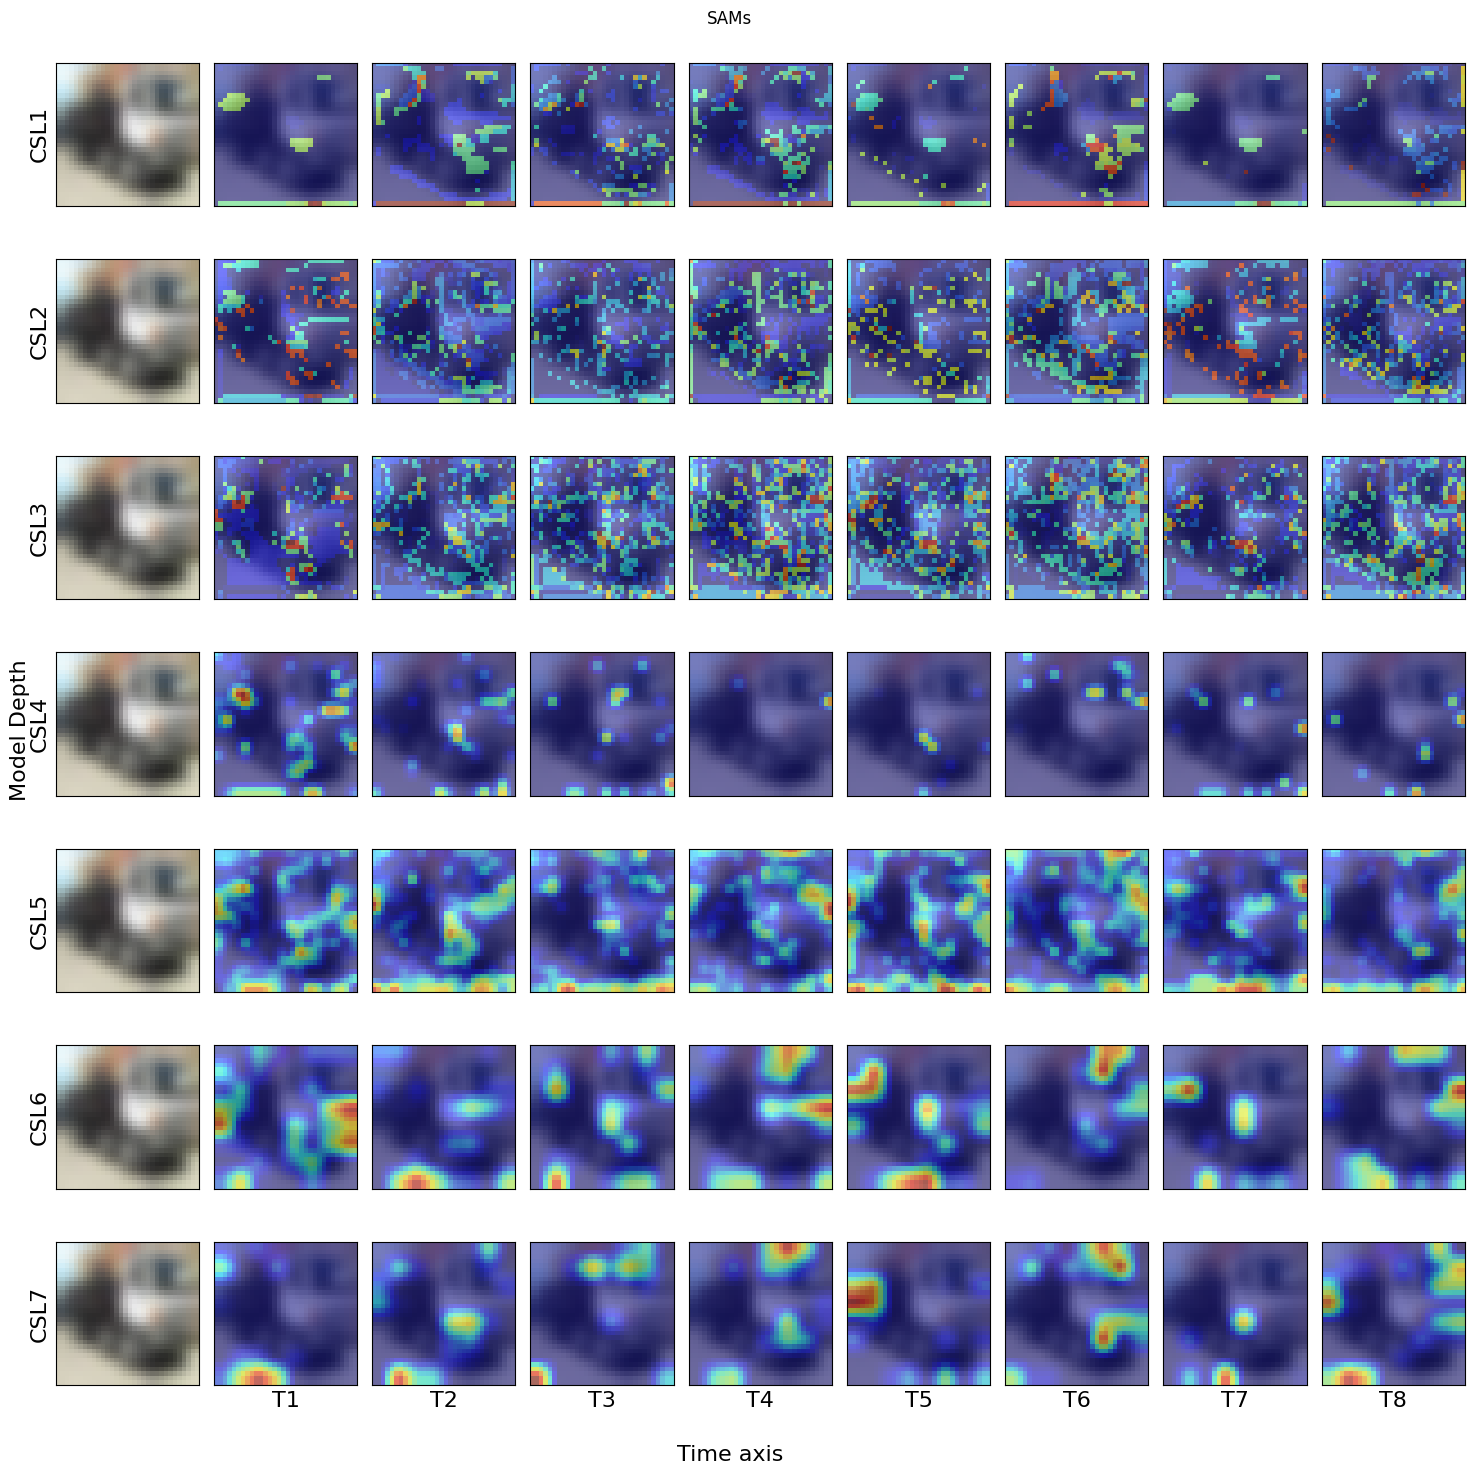

In [ ]:
fig, axs = plt.subplots(7, 9, figsize=(15,15), sharex=True, sharey=True)

input_show = inv_transform(sample_input[0, sample_no:sample_no+1][0])
input_show = torch.clamp(input_show, 0, 1).permute(1,2,0)
for i,ax in enumerate(axs[:, 0]):
    ax.imshow(input_show)
    ax.set_ylabel(f'CSL{i+1}', fontsize=16)

ax.set_xticks([],[])
ax.set_yticks([],[])

avg_cam = []

for li, layer_name in enumerate(outgrad_monitor.monitored_layers[:7]):
    lcams = []
    for t in range(T):
        A = act_monitor.records[li][t, 0]          # [C, H, W]
        G = outgrad_monitor.records[::-1][li][t, 0]         # [C, H, W]

        w = G.mean(dim=(1,2))
        cam = (w[:,None,None] * A).sum(dim=0)
        cam = torch.relu(cam)
        cam = cam / (cam.max() + 1e-12)

        cam_up = torch.nn.functional.interpolate(
            cam[None, None],
            size=(32,32),
            mode='bilinear',
            align_corners=False
        )[0,0]
        lcams.append(cam_up.cpu().detach().numpy())
    avg_cam.append(np.mean(lcams, axis=0))
    for ti,ax in enumerate(axs[li, 1:]):
        ax.imshow(input_show)
        ax.imshow(lcams[ti], alpha=0.5, cmap = 'jet', vmax=1, vmin=0)
        if li == 6:
            ax.set_xlabel(f'T{ti+1}', fontsize=16)

fig.supxlabel('Time axis', fontsize=16)
fig.supylabel('Model Depth', fontsize=16)
fig.suptitle('SAMs')
fig.tight_layout()

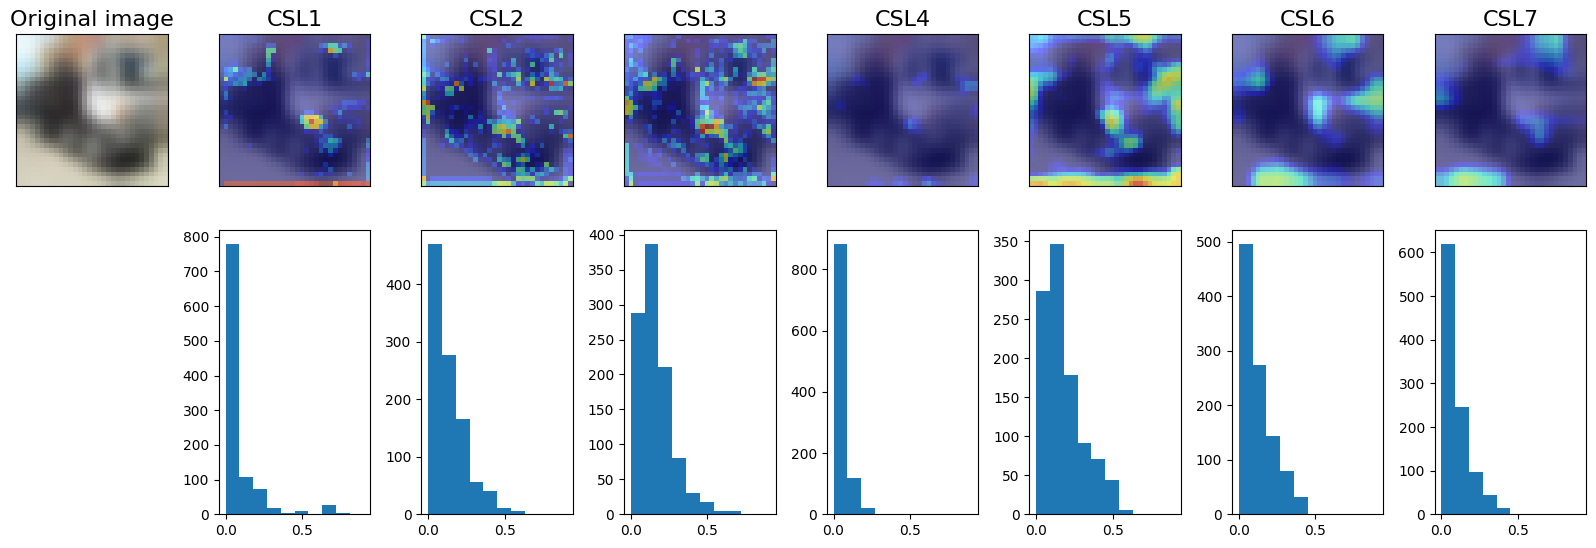

In [ ]:
fig, axs = plt.subplots(2, 8, figsize=(16,6))

input_show = inv_transform(sample_input[0, sample_no:sample_no+1][0])
input_show = torch.clamp(input_show, 0, 1).permute(1,2,0)
for i,(ax, bax) in enumerate(zip(axs[0], axs[1])):
    ax.imshow(input_show)
    ax.set_xticks([])
    ax.set_yticks([])
    if i == 0:
        ax.set_title('Original image', fontsize=16)
    else:
        ax.imshow(avg_cam[i-1], alpha=0.5, cmap = 'jet', vmax=0.7, vmin=0.1)
        ax.set_title(f'CSL{i}', fontsize=16)
        bax.hist(avg_cam[i-1].ravel(), bins=10, range=(0,0.9))
axs[1, 0].set_visible(False)

fig.tight_layout()

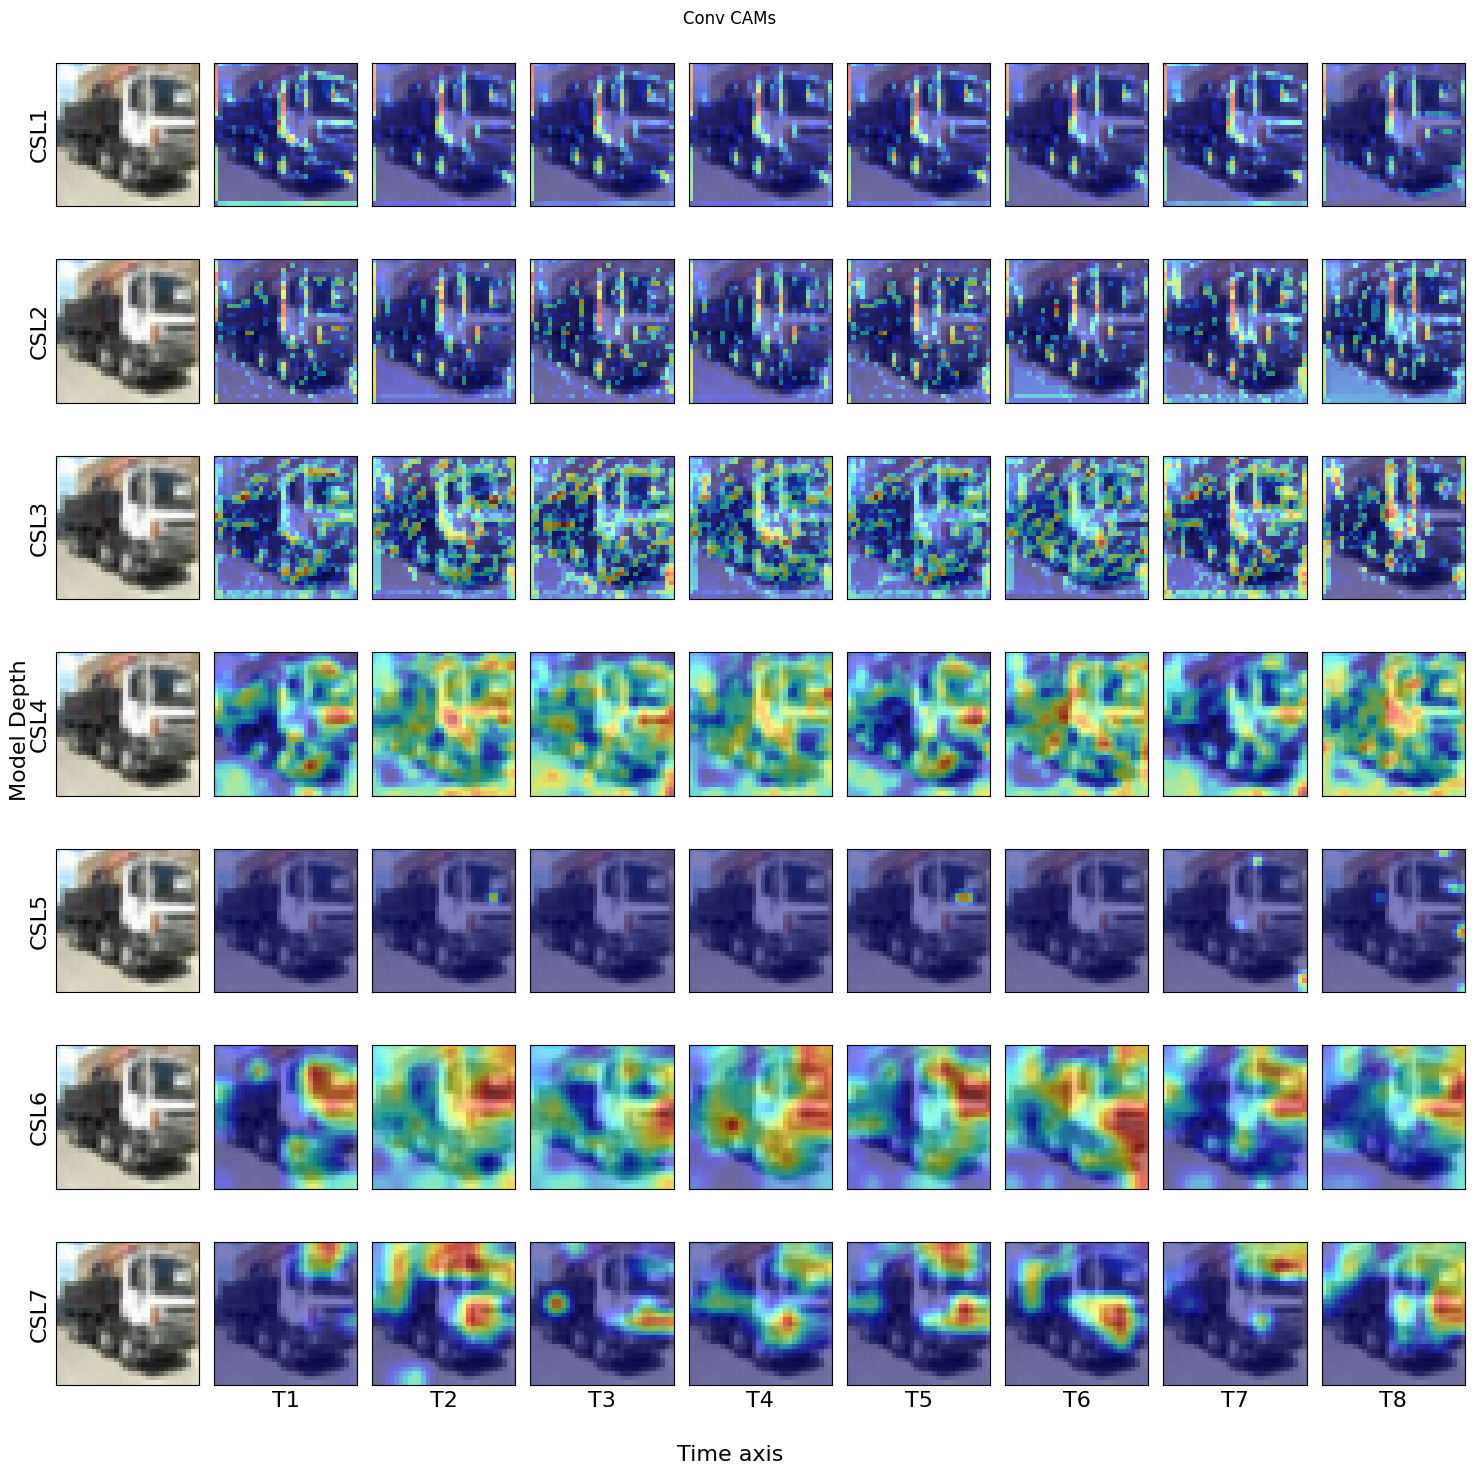

In [ ]:
fig, axs = plt.subplots(7, 9, figsize=(15,15), sharex=True, sharey=True)

input_show = inv_transform(sample_input[0, sample_no:sample_no+1][0])
input_show = torch.clamp(input_show, 0, 1).permute(1,2,0)
for i,ax in enumerate(axs[:, 0]):
    ax.imshow(input_show)
    ax.set_ylabel(f'CSL{i+1}', fontsize=16)

ax.set_xticks([],[])
ax.set_yticks([],[])

convavg_cam = []

for li, layer_name in enumerate(outgrad_monitor.monitored_layers[:7]):
    lcams = []
    for t in range(T):
        A = convact_monitor.records[li][t, 0]          # [C, H, W]
        G = convgrad_monitor.records[::-1][li][t, 0]         # [C, H, W]

        w = G.mean(dim=(1,2))
        cam = (w[:,None,None] * A).sum(dim=0)
        cam = torch.relu(cam)
        cam = cam / (cam.max() + 1e-12)

        cam_up = torch.nn.functional.interpolate(
            cam[None, None],
            size=(32,32),
            mode='bilinear',
            align_corners=False
        )[0,0]
        lcams.append(cam_up.cpu().detach().numpy())
    convavg_cam.append(np.mean(lcams, axis=0))
    for ti,ax in enumerate(axs[li, 1:]):
        ax.imshow(input_show)
        ax.imshow(lcams[ti], alpha=0.5, cmap = 'jet', vmax=1, vmin=0)
        if li == 6:
            ax.set_xlabel(f'T{ti+1}', fontsize=16)

fig.supxlabel('Time axis', fontsize=16)
fig.supylabel('Model Depth', fontsize=16)
fig.suptitle('Conv CAMs')
fig.tight_layout()

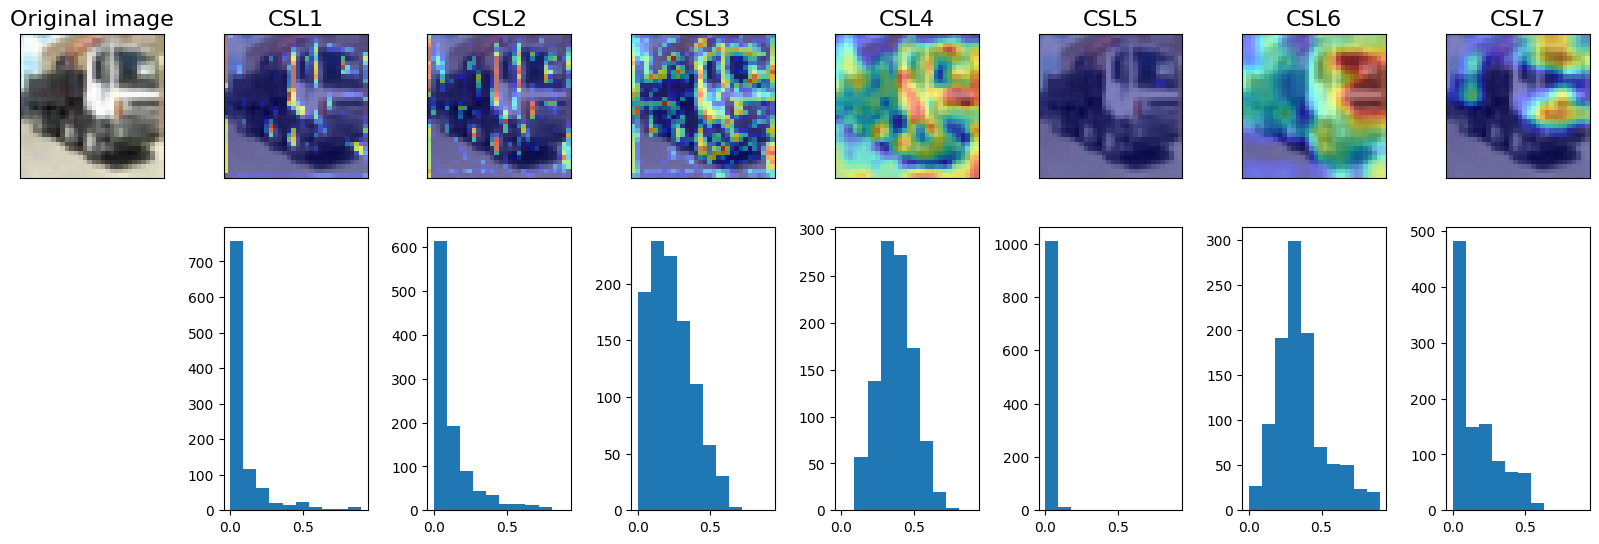

In [ ]:
fig, axs = plt.subplots(2, 8, figsize=(16,6))

input_show = inv_transform(sample_input[0, sample_no:sample_no+1][0])
input_show = torch.clamp(input_show, 0, 1).permute(1,2,0)
for i,(ax, bax) in enumerate(zip(axs[0], axs[1])):
    ax.imshow(input_show)
    ax.set_xticks([])
    ax.set_yticks([])
    if i == 0:
        ax.set_title('Original image', fontsize=16)
    else:
        ax.imshow(convavg_cam[i-1], alpha=0.5, cmap = 'jet', vmax=0.7, vmin=0.1)
        ax.set_title(f'CSL{i}', fontsize=16)
        bax.hist(convavg_cam[i-1].ravel(), bins=10, range=(0,0.9))
axs[1, 0].set_visible(False)

fig.tight_layout()

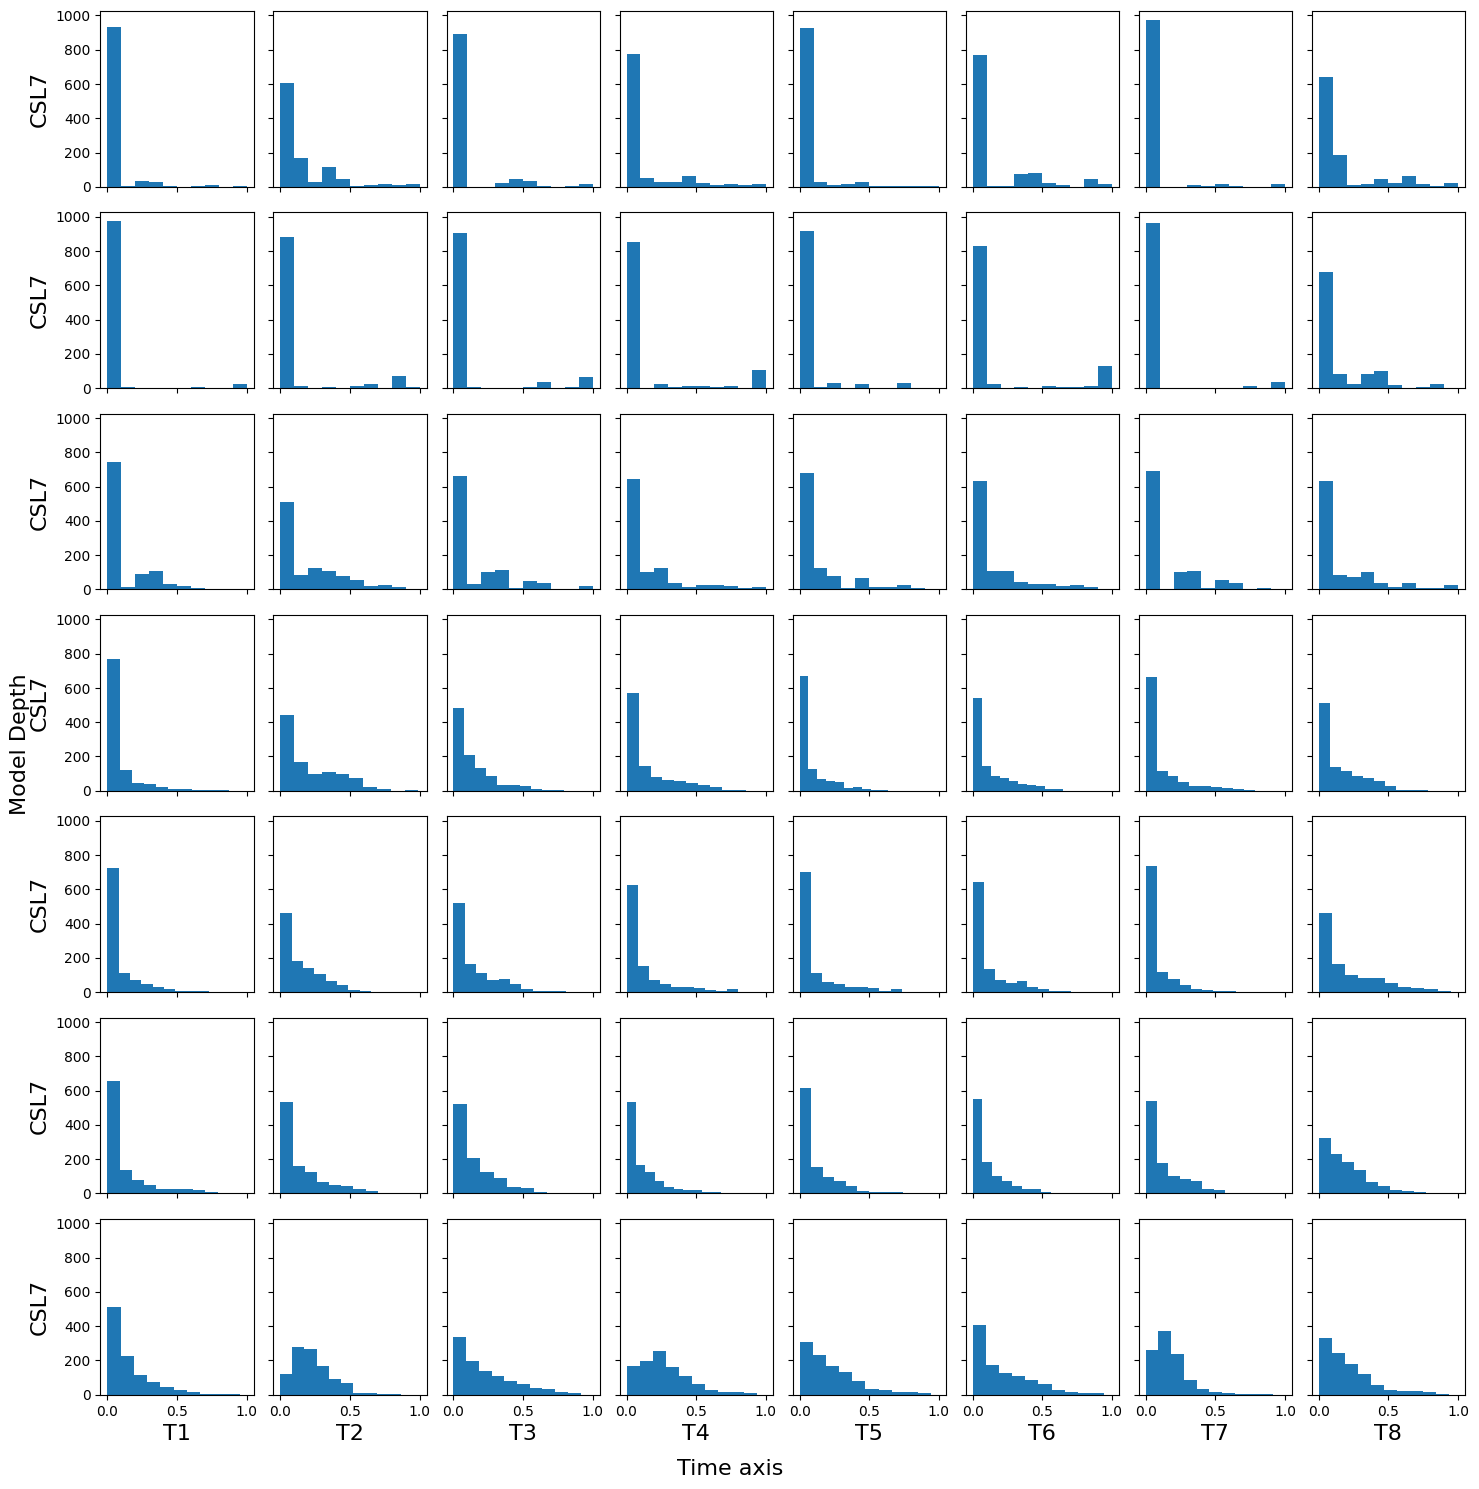

In [ ]:
fig, axs = plt.subplots(7, 8, figsize=(15,15), sharex=True, sharey=True)


for li, layer in enumerate(outgrad_monitor.monitored_layers[:7]):
    lcams = []
    for t in range(T):
        A = act_monitor.records[li][t, 0]          # [C, H, W]
        G = outgrad_monitor.records[::-1][li][t, 0]         # [C, H, W]

        w = G.mean(dim=(1,2))
        cam = (w[:,None,None] * A).sum(dim=0)
        cam = torch.relu(cam)
        cam = cam / (cam.max() + 1e-12)

        cam_up = torch.nn.functional.interpolate(
            cam[None, None],
            size=(32,32),
            mode='bilinear',
            align_corners=False
        )[0,0]
        lcams.append(cam_up.cpu().detach().numpy())
    for ti,ax in enumerate(axs[li]):
        ax.hist(lcams[ti].ravel())
        if ti == 0:
            ax.set_ylabel(f'CSL{i+1}', fontsize=16)
        if li == 6:
            ax.set_xlabel(f'T{ti+1}', fontsize=16)


fig.supxlabel('Time axis', fontsize=16)
fig.supylabel('Model Depth', fontsize=16)
fig.tight_layout()

IndexError: index 20 is out of bounds for dimension 0 with size 20

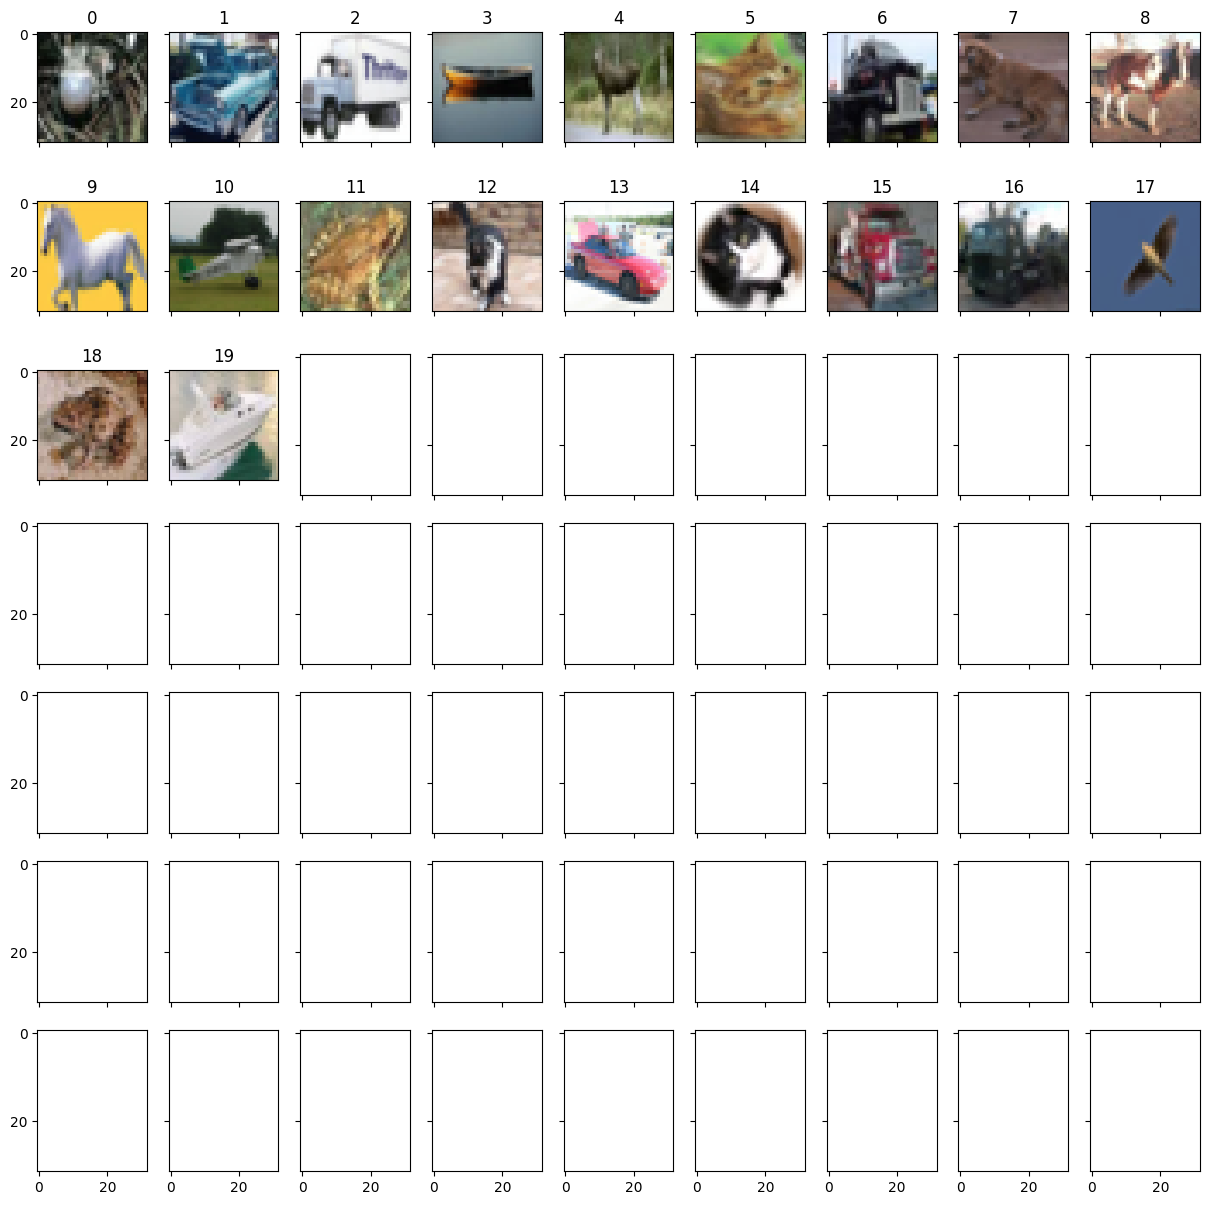

In [ ]:
fig, axs = plt.subplots(7, 9, figsize=(15,15), sharex=True, sharey=True)


for i,ax in enumerate(axs.ravel()):
    input_show = inv_transform(imgs[-1][i])
    input_show = torch.clamp(input_show, 0, 1).permute(1,2,0)
    ax.imshow(input_show)
    ax.set_title(i)
ax.set_xticks([],[])
ax.set_yticks([],[])

In [ ]:
options = -17, -22, 41, 15, 40,

In [ ]:
tensor([ 0,  1, 11, 12, 15, 19, 20, 23, 24, 28, 29, 32, 34, 36, 39, 40, 49, 50,
         51, 52, 55, 57, 59, 60, 63, 65, 67, 69, 73, 77, 81, 83, 86, 87, 90, 96]),)



### Grad CAM Run

In [ ]:
def net_layer_to_names(layers):
    out = []
    counts = {"DSL": 0, "CSL": 0, "Down": 0}
    for n in layers:
        if n.startswith("fc."):
            key = "DSL"
        elif "downsample" in n:
            key = "Down"
        else:
            key = "CSL"
        counts[key] += 1
        out.append(f"{key}{counts[key]}")
    return out



In [ ]:
paths = glob.glob('/content/drive/MyDrive/FORTH/Colab Codes/models/C100*T8_*KS32_FullSNN_Small*/checkpoint_max*')
paths


['/content/drive/MyDrive/FORTH/Colab Codes/models/C100_T8_[KS32_FullSNN_Small_FRReg]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/checkpoint_max.pth',
 '/content/drive/MyDrive/FORTH/Colab Codes/models/C100_T8_[KS32_FullSNN_Small]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/checkpoint_max.pth']

In [ ]:
# net = sew_resnet18(cnf = 'ADD', spiking_neuron=PLIFNode).to(device)
device = 'cpu'
step_mode = 'm'
init_tau = 2.0
detach_reset = True
class_num = 100
cnf = 'ADD'
surrogate_function = surrogate.ATan()
bn_momentum = 0.1
T = 8

# net = sew_resnet18(cnf = 'ADD', spiking_neuron=PLIFNode).to(device)
net = KS32_FullySpiking_Small(BasicBlock, [1,1,1], num_classes = class_num, bn_momentum=bn_momentum,
                        cnf=cnf , spiking_neuron=PLIFNode, init_tau=init_tau, detach_reset=detach_reset, surrogate_function=surrogate_function).to(device)
functional.set_step_mode(net, step_mode=step_mode)


In [ ]:
# path = glob.glob(r'./models/C100_T[4]_[GD]_PLIF[SEWResNet_2222_mp]_bn[0.9]_tau[2.0]_batch[200]_cnf[ADD]/checkpoint*max.pth')[0]
# path = r'./models/C100_T[4]_[GD]_PLIF[SEWResNet_2222_mp]_bn[0.9]_tau[2.0]_batch[200]_cnf[ADD]/checkpoint_max.pth'
path = paths[0]
net, end_epoch, max_test_acc = load_checkpoint(net, path, device)



In [ ]:
def cal_firing_rate(s_seq: torch.Tensor):
    return s_seq.mean()

In [ ]:
outgrad_monitor = monitor.GradOutputMonitor(net, PLIFNode)
act_monitor = monitor.OutputMonitor(net, PLIFNode)

In [ ]:
output_layer_names = net_layer_to_names(act_monitor.monitored_layers)
output_layer_names

['CSL1',
 'CSL2',
 'CSL3',
 'Down1',
 'CSL4',
 'CSL5',
 'Down2',
 'CSL6',
 'CSL7',
 'DSL1',
 'DSL2']

In [ ]:
num_classes = 100
batch_size = 100
T = 8
N = 10
L = len(act_monitor.monitored_layers)

In [ ]:
cams_sum = {layer_name: {c: 0.0 for c in range(num_classes)} for layer_name in output_layer_names}
importance_sum = {layer_name: {c: 0.0 for c in range(num_classes)} for layer_name in output_layer_names}

counts = torch.zeros(num_classes, dtype=torch.long)

In [ ]:
dataset = TransformDataset(base_dataset, ['blurS', 'blurM', 'blurL'], data_transformers)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)


In [ ]:

net.eval()

for imgs, y in loader:
    x = imgs[-1].unsqueeze(0).repeat(T,1,1,1,1).to(device)
    y = y.to(device)

    # reset monitors
    outgrad_monitor.clear_recorded_data()
    act_monitor.clear_recorded_data()
    functional.reset_net(net)

    out = net(x)

    for i in range(batch_size):
        if np.mod(i, 10)==0:
            print(i)
        c = y[i].item()
        if counts[c] >= N:
            continue

        net.zero_grad()
        out[:, i, c].sum().backward(retain_graph=True)

        for li, layer_name in zip(range(L), output_layer_names):
            if 'D' in layer_name:
                continue

            importance_sum_t = 0.0
            for t in range(T):
                A = act_monitor.records[li][t, i]           # [C,H,W]
                G = outgrad_monitor.records[::-1][li][t, i] # [C,H,W]

                w = G.mean(dim=(1,2))                      # [C]
                a = A.mean(dim=(1,2))                      # [C]
                importance_sum_t += (w * a)

                # cam = (w[:, None, None] * A).sum(dim=0)    # [H,W]
                # cam = torch.relu(cam)
                # cam = cam / (cam.max() + 1e-12)
                # cam_up = torch.nn.functional.interpolate(
                #     cam[None,None],
                #     size=(32,32),
                #     mode="bilinear",
                #     align_corners=False
                # )[0,0]

                # if isinstance(cams_sum[layer_name][c], float) or isinstance(cams_sum[layer_name][c], int):
                #     cams_sum[layer_name][c] = cam_up.clone()
                # else:
                #     cams_sum[layer_name][c] += cam_up

            # accumulate importance
            importance_final = importance_sum_t / T
            if isinstance(importance_sum[layer_name][c], float) or isinstance(importance_sum[layer_name][c], int):
                importance_sum[layer_name][c] = importance_final.clone()
            else:
                importance_sum[layer_name][c] += importance_final

        counts[c] += 1

    if (counts >= N).all():
        break

# Final averaging
# final_cams = {layer: {c: cams_sum[layer][c] / counts[c] for c in range(num_classes)} for layer in output_layer_names}
final_importance = {layer: {c: importance_sum[layer][c] / counts[c] for c in range(num_classes)} for layer in output_layer_names}


0
10
20
30
40
50


KeyboardInterrupt: 

torch.Size([8, 100, 16, 16, 16])

In [ ]:


net.eval()

for imgs, y in loader:
    x = imgs[-1].unsqueeze(0).repeat(T,1,1,1,1).to(device)
    y = y.to(device)

    # run forward once for whole batch
    outgrad_monitor.clear_recorded_data()
    act_monitor.clear_recorded_data()
    functional.reset_net(net)

    out = net(x)

    for i in range(batch_size):
        c = y[i].item()
        if counts[c] >= N:
            continue

        # --- backward on only this sample + class ---
        net.zero_grad()
        out[:, i, c].sum().backward(retain_graph=True)

        # --- compute GradCAM for ALL layers ---
        for li, layer_name in zip(range(L), output_layer_names):
            if 'Down' in layer_name:
                continue
            lcams = []  # T heatmaps

            for t in range(T):
                # activations (feature maps)
                A = act_monitor.records[li][t, i]           # [C,H,W]
                # gradients w.r.t output of layer
                G = outgrad_monitor.records[::-1][li][t, i] # [C,H,W]

                w = G.mean(dim=(1, 2))                      # [C]
                a = A.mean(dim=(1, 2))                      # [C]
                importance_t = (w * a)
                if t == 0:
                    importance_sum = importance_t.clone()
                else:
                    importance_sum += importance_t
                cam = (w[:, None, None] * A).sum(dim=0)     # [H,W]
                cam = torch.relu(cam)
                cam = cam / (cam.max() + 1e-12)

                cam_up = torch.nn.functional.interpolate(
                    cam[None, None],
                    size=(32, 32),
                    mode="bilinear",
                    align_corners=False
                )[0, 0]

                lcams.append(cam_up.detach().cpu())

            cams[layer_name][c].append(torch.stack(lcams))  # [T,32,32]

            importance_final = importance_sum / T   # [C]
            importance[layer_name][c].append(importance_final.cpu())

        counts[c] += 1

    # stop if all classes reached N
    if (counts >= N).all():
        break

# --------------------------
# Convert lists → stacked tensors
# cams[layer][c] = [num_samples,T,32,32]
# --------------------------

for layer in cams:
    for c in range(num_classes):
        if len(cams[layer][c]) > 0:
            cams[layer][c] = torch.stack(cams[layer][c])
        else:
            cams[layer][c] = None


torch.Size([8, 500, 100])

## Ablation CAM testing

### Sample Input

In [ ]:
batch_size = 100
dataset = TransformDataset(base_dataset, ['blurS', 'blurM'], data_transformers)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [ ]:
imgs, labels = next(iter(loader))

In [ ]:
imgs[-1].shape

torch.Size([1000, 3, 32, 32])

In [ ]:
inv_transform = transforms.Normalize(
    mean=[-m/s for m, s in zip((0.4914, 0.4822, 0.4465),
                               (0.2023, 0.1994, 0.2010))],
    std=[1/s for s in (0.2023, 0.1994,  0.2010)]
)

### Net Set Up


In [ ]:
class AblationLayer(nn.Module):
    def __init__(self, shape):
        super().__init__()
        self.register_buffer("mask", torch.ones(shape))

    def forward(self, x):
        return x * self.mask


In [ ]:
# paths = glob.glob('/content/drive/MyDrive/FORTH/Colab Codes/models/C100*T8_*KS32_FullSNN_Small*/checkpoint_max*')
paths = glob.glob('/content/drive/MyDrive/FORTH/Colab Codes/models/C10_*/checkpoint_max*')
paths


['/content/drive/MyDrive/FORTH/Colab Codes/models/C10_T8_[KS32_FullSNN_Small]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/checkpoint_max.pth',
 '/content/drive/MyDrive/FORTH/Colab Codes/models/C10_T8_[KS32_FullySpiking_Small_ForwardBlock]_bn[0.1]_tau[2.0]_batch[250]/checkpoint_max.pth']

In [ ]:
# net = sew_resnet18(cnf = 'ADD', spiking_neuron=PLIFNode).to(device)
device = 'cpu'
step_mode = 'm'
init_tau = 2.0
detach_reset = True
class_num = 10
cnf = 'ADD'
surrogate_function = surrogate.ATan()
bn_momentum = 0.1
T = 8

# net = sew_resnet18(cnf = 'ADD', spiking_neuron=PLIFNode).to(device)
net = KS32_FullySpiking_Small(BasicBlock, [1,1,1], num_classes = class_num, bn_momentum=bn_momentum,
                        cnf=cnf , spiking_neuron=PLIFNode, init_tau=init_tau, detach_reset=detach_reset, surrogate_function=surrogate_function).to(device)
# net = KS32_FullySpiking_Small(ForwardBlock, [1,1,1], num_classes = class_num, bn_momentum=bn_momentum,
#                         cnf=cnf , spiking_neuron=PLIFNode, init_tau=init_tau, detach_reset=detach_reset, surrogate_function=surrogate_function).to(device)
functional.set_step_mode(net, step_mode=step_mode)


In [ ]:
# path = glob.glob(r'./models/C100_T[4]_[GD]_PLIF[SEWResNet_2222_mp]_bn[0.9]_tau[2.0]_batch[200]_cnf[ADD]/checkpoint*max.pth')[0]
# path = r'./models/C100_T[4]_[GD]_PLIF[SEWResNet_2222_mp]_bn[0.9]_tau[2.0]_batch[200]_cnf[ADD]/checkpoint_max.pth'
path = paths[0]
net, end_epoch, max_test_acc = load_checkpoint(net, path, device)




In [ ]:
net

KS32_FullySpiking_Small(
  (layer1): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, step_mode=m)
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True, step_mode=m)
    (2): ParametricLIFNode(
      v_threshold=1.0, v_reset=0.0, detach_reset=True, step_mode=m, backend=torch, tau=1.8902193307876587
      (surrogate_function): ATan(alpha=2.0, spiking=True)
    )
  )
  (layer2): Sequential(
    (0): BasicBlock(
      cnf=ADD
      (downsample): Sequential()
      (residual_function): Sequential(
        (0): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, step_mode=m)
        (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True, step_mode=m)
        (2): ParametricLIFNode(
          v_threshold=1.0, v_reset=0.0, detach_reset=True, step_mode=m, backend=torch, tau=1.515742301940918
          (surrogate_function): ATan(alpha=2.0, spiking=True)
        )

In [ ]:
sample_input.shape

torch.Size([8, 20, 3, 32, 32])

In [ ]:
input_monitor = monitor.InputMonitor(net, layer.Conv2d)
input_monitor.monitored_layers

['layer1.0',
 'layer2.0.residual_function.0',
 'layer2.0.residual_function.3',
 'layer3.0.downsample.0',
 'layer3.0.residual_function.0',
 'layer3.0.residual_function.3',
 'layer4.0.downsample.0',
 'layer4.0.residual_function.0',
 'layer4.0.residual_function.3']

In [ ]:
act_monitor = monitor.OutputMonitor(net, PLIFNode)
act_monitor.monitored_layers

['layer1.2',
 'layer2.0.residual_function.2',
 'layer2.0.residual_function.5',
 'layer3.0.downsample.2',
 'layer3.0.residual_function.2',
 'layer3.0.residual_function.5',
 'layer4.0.downsample.2',
 'layer4.0.residual_function.2',
 'layer4.0.residual_function.5',
 'fc.2',
 'fc.4']

In [ ]:
net.eval()

with torch.no_grad():
    functional.reset_net(net)
    act_monitor.clear_recorded_data()
    input_monitor.clear_recorded_data()
    sample_output = net(sample_input)

In [ ]:
for net_idx,j,ch in zip([net.layer2, net.layer2, net.layer3, net.layer3, net.layer4, net.layer4], [2,5,2,5,2,5], [8,8,16,16,32,32]):
    plif_layer = net_idx[0].residual_function[j]

    net_idx[0].residual_function[j] = nn.Sequential(
        plif_layer,
        AblationLayer((1,1,ch,1,1))
    )

In [ ]:
net

KS32_FullySpiking_Small(
  (layer1): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, step_mode=m)
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True, step_mode=m)
    (2): ParametricLIFNode(
      v_threshold=1.0, v_reset=0.0, detach_reset=True, step_mode=m, backend=torch, tau=1.8902193307876587
      (surrogate_function): ATan(alpha=2.0, spiking=True)
    )
  )
  (layer2): Sequential(
    (0): BasicBlock(
      cnf=ADD
      (downsample): Sequential()
      (residual_function): Sequential(
        (0): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, step_mode=m)
        (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True, step_mode=m)
        (2): Sequential(
          (0): ParametricLIFNode(
            v_threshold=1.0, v_reset=0.0, detach_reset=True, step_mode=m, backend=torch, tau=1.515742301940918
            (surrogate_function): ATan(alp

In [ ]:
ablation_input = monitor.InputMonitor(net, AblationLayer)
ablation_output = monitor.OutputMonitor(net, AblationLayer)

In [ ]:
net.eval()

with torch.no_grad():
    functional.reset_net(net)
    act_monitor.clear_recorded_data()
    input_monitor.clear_recorded_data()
    ablation_input.clear_recorded_data()
    ablation_output.clear_recorded_data()
    check_output = net(sample_input)

In [ ]:
for li, lname in enumerate(ablation_input.monitored_layers):
    print(lname, (ablation_input.records[li]==ablation_output.records[li]).all(), ablation_input.records[li].shape, ablation_output.records[li].shape)

layer2.0.residual_function.2.1 tensor(True) torch.Size([8, 20, 8, 32, 32]) torch.Size([8, 20, 8, 32, 32])
layer2.0.residual_function.5.1 tensor(True) torch.Size([8, 20, 8, 32, 32]) torch.Size([8, 20, 8, 32, 32])
layer3.0.residual_function.2.1 tensor(True) torch.Size([8, 20, 16, 16, 16]) torch.Size([8, 20, 16, 16, 16])
layer3.0.residual_function.5.1 tensor(True) torch.Size([8, 20, 16, 16, 16]) torch.Size([8, 20, 16, 16, 16])
layer4.0.residual_function.2.1 tensor(True) torch.Size([8, 20, 32, 8, 8]) torch.Size([8, 20, 32, 8, 8])
layer4.0.residual_function.5.1 tensor(True) torch.Size([8, 20, 32, 8, 8]) torch.Size([8, 20, 32, 8, 8])


In [ ]:
sample_output[0][0]

tensor([-9.9219, -7.6545, -3.1650, -3.8568,  4.7660, -1.5429, -1.2320,  2.1259,
        -6.5943, -8.3331], grad_fn=<SelectBackward0>)

In [ ]:
(ablation_input.records[li] == ablation_output.records[li])

tensor([True])

In [ ]:
check_output[0][0]

tensor([-10.7463, -13.3119,  -2.7219,  -8.7570,   5.7378,  -1.3224,  -8.9908,
          3.9840, -12.5663, -12.6101], grad_fn=<SelectBackward0>)

In [ ]:
ablation_input = monitor.InputMonitor(net, AblationLayer)
ablation_output = monitor.OutputMonitor(net, AblationLayer)

In [ ]:
(sample_output == check_output).all()

tensor(True)

In [ ]:
torch.abs(sample_output - check_output).mean()

tensor(2.0503, grad_fn=<MeanBackward0>)

In [ ]:
(act_monitor.records[0] == input_monitor.records[1]).all()

tensor(True)

In [ ]:
(act_monitor.records[1] == input_monitor.records[2]).all()

tensor(True)

In [ ]:
for li, layer in enumerate(act_monitor.monitored_layers):
    print(layer, act_monitor.records[li].shape[2])

layer1.2 8
layer2.0.residual_function.2 8
layer2.0.residual_function.5 8
layer3.0.downsample.2 16
layer3.0.residual_function.2 16
layer3.0.residual_function.5 16
layer4.0.downsample.2 32
layer4.0.residual_function.2 32
layer4.0.residual_function.5 32
fc.2 1024
fc.4 1024


### Run

In [ ]:
sample_input = imgs[-1].unsqueeze(0).repeat(T,1,1,1,1).to(device)
sample_input.shape, labels.shape

(torch.Size([8, 100, 3, 32, 32]), torch.Size([100]))

In [ ]:
np.unique(labels, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 array([10, 14, 13,  6,  5,  8, 13,  9, 11, 11]))

In [ ]:
# Add Ablation layer with Spatial Dims
plif_layer = net.layer1[2]

net.layer1[2] = nn.Sequential(
        plif_layer,
        AblationLayer((1,1,1,32,32))
    )

for net_idx,lx,sz in zip([net.layer2, net.layer2, net.layer3, net.layer3, net.layer4, net.layer4], [2,5,2,5,2,5], [32, 32, 16, 16, 8, 8]):
    plif_layer = net_idx[0].residual_function[lx]

    net_idx[0].residual_function[lx] = nn.Sequential(
        plif_layer,
        AblationLayer((1,1,1,sz,sz))
    )

In [ ]:
ablation_output = monitor.OutputMonitor(net, AblationLayer)

In [ ]:
all_CAMs = {}

In [ ]:
li = 0
lname = ablation_output.monitored_layers[li]
print(lname)
# ablation_layer = net.layer4[0].residual_function[5][1]
ablation_layer = net.layer1[2][1]
ablation_layer.mask.shape

layer1.2.1


torch.Size([1, 1, 1, 32, 32])

In [ ]:
target_class = 4
input_tensor = sample_input[:, labels==target_class]
# baseline output
sample_no = 0
input_tensor = input_tensor[:, sample_no:sample_no+1]
net.eval()
functional.reset_net(net)
with torch.no_grad():
    ablation_output.clear_recorded_data()
    out_clean = net(input_tensor)  # [B, num_classes]
out_clean.shape

torch.Size([8, 1, 10])

In [ ]:
activations = ablation_output.records[li]
T, B, C, H, W = activations.shape
ablationCAM = torch.zeros(T, H, W, device=device)

In [ ]:
# slide over all spatial positions

for i in range(H):
    print(i, end = ' ')
    for j in range(W):
        # zero out patch at (i,j)
        ablation_layer.mask[:] = 1.0
        ablation_layer.mask[:, :, :, i:i+1, j:j+1] = 0.0

        # forward pass with ablation
        functional.reset_net(net)
        with torch.no_grad():
            out_ablate = net(input_tensor)

        for t in range(T):
            # score difference for this timestep
            score_diff = (out_clean[t, :, target_class] - out_ablate[t, :, target_class])  # [B]
            score_diff_mean = score_diff.mean()  # scalar

            # norm of activation patch at this timestep
            patch_norm = torch.norm(activations[t, :, :, i, j]) + 1e-12

            # canonical AblationCAM: ReLU(w * activation)
            # here we average over batch and sum channels
            ablationCAM[t, i, j] = F.relu(
                score_diff_mean / patch_norm * activations[t, :, :, i, j].mean()
            )

# reset mask
ablation_layer.mask[:] = 1.0

# project to input size (naive upsampling)
ablationCAM_up = F.interpolate(
    ablationCAM.unsqueeze(0),  # add batch dim
    size=(input_tensor.shape[-2], input_tensor.shape[-1]),
    mode='bilinear',
    align_corners=False
).squeeze(0)  # [T, H_in, W_in]


0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 

In [ ]:
all_CAMs[li] = ablationCAM_up
all_CAMs.keys()

dict_keys([1, 2, 3, 4, 5, 6, 0])

np.float32(0.5320377)

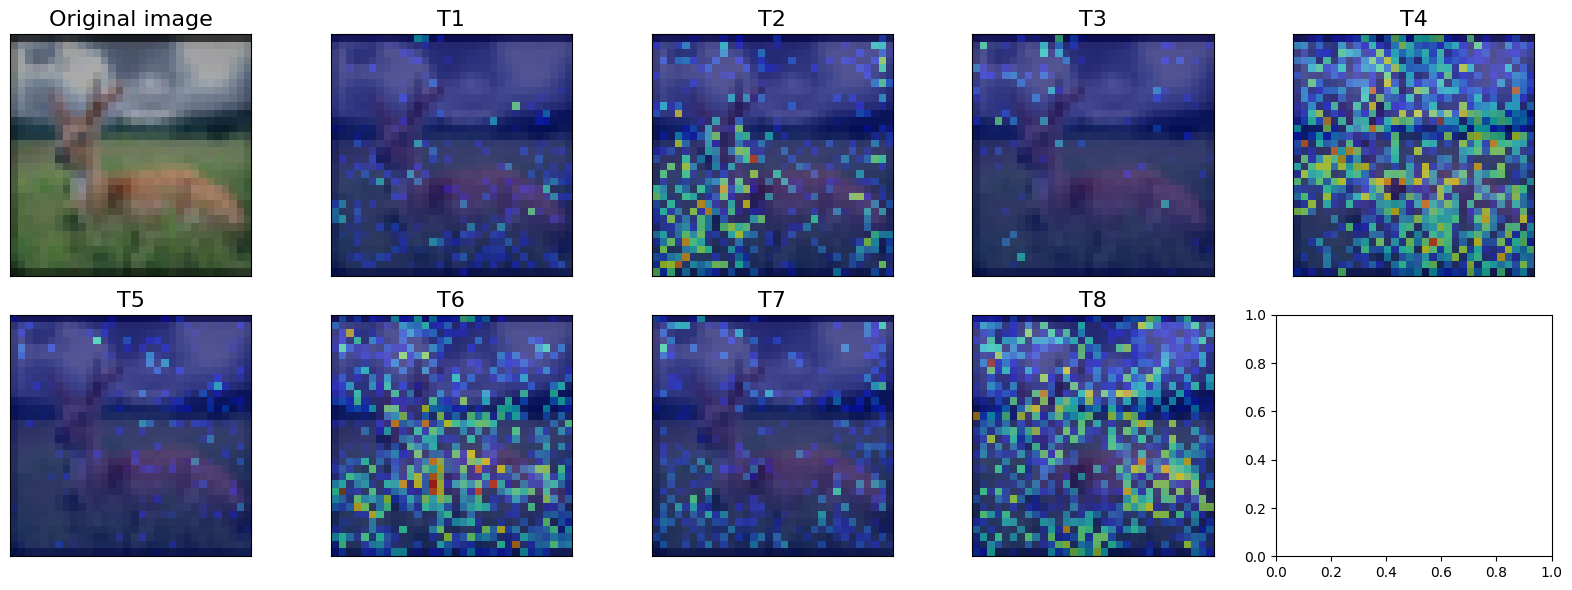

In [ ]:
fig, axs = plt.subplots(2, 5, figsize=(16,6))

input_show = inv_transform(input_tensor[0, 0:1][0])
input_show = torch.clamp(input_show, 0, 1).permute(1,2,0)
for i,ax in enumerate(axs.ravel()[:-1]):
    ax.imshow(input_show)
    ax.set_xticks([])
    ax.set_yticks([])
    if i == 0:
        ax.set_title('Original image', fontsize=16)
    else:
        ax.imshow(ablationCAM_up[i-1]/ablationCAM_up.max(), alpha=0.5, cmap = 'jet', vmax=1, vmin=0)
        ax.set_title(f'T{i}', fontsize=16)
# axs[1, 0].set_visible(False)

fig.tight_layout()




[]

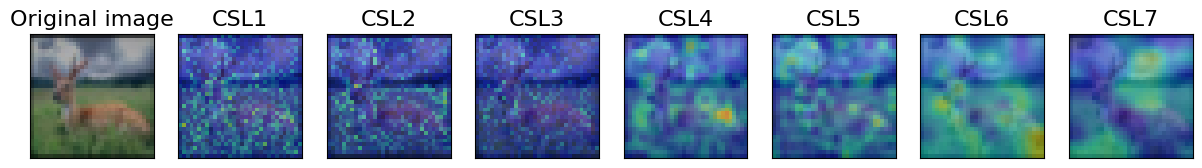

In [ ]:
fig, axs = plt.subplots(1, 8, figsize=(15,5), sharex=True, sharey=True)

input_show = inv_transform(input_tensor[0, 0:1][0])
input_show = torch.clamp(input_show, 0, 1).permute(1,2,0)
for i,ax in enumerate(axs.ravel()):
    ax.imshow(input_show)
    if i == 0:
        ax.set_title('Original image', fontsize=16)
    else:
        ax.set_title(f'CSL{i}', fontsize=16)

for li, lcams in all_CAMs.items():
    norm = lcams.max()
    axs.ravel()[li+1].imshow((lcams/norm).mean(dim=0), alpha=0.4, cmap = 'jet', vmax=0.5, vmin=0)

ax.set_xticks([],[])
ax.set_yticks([],[])

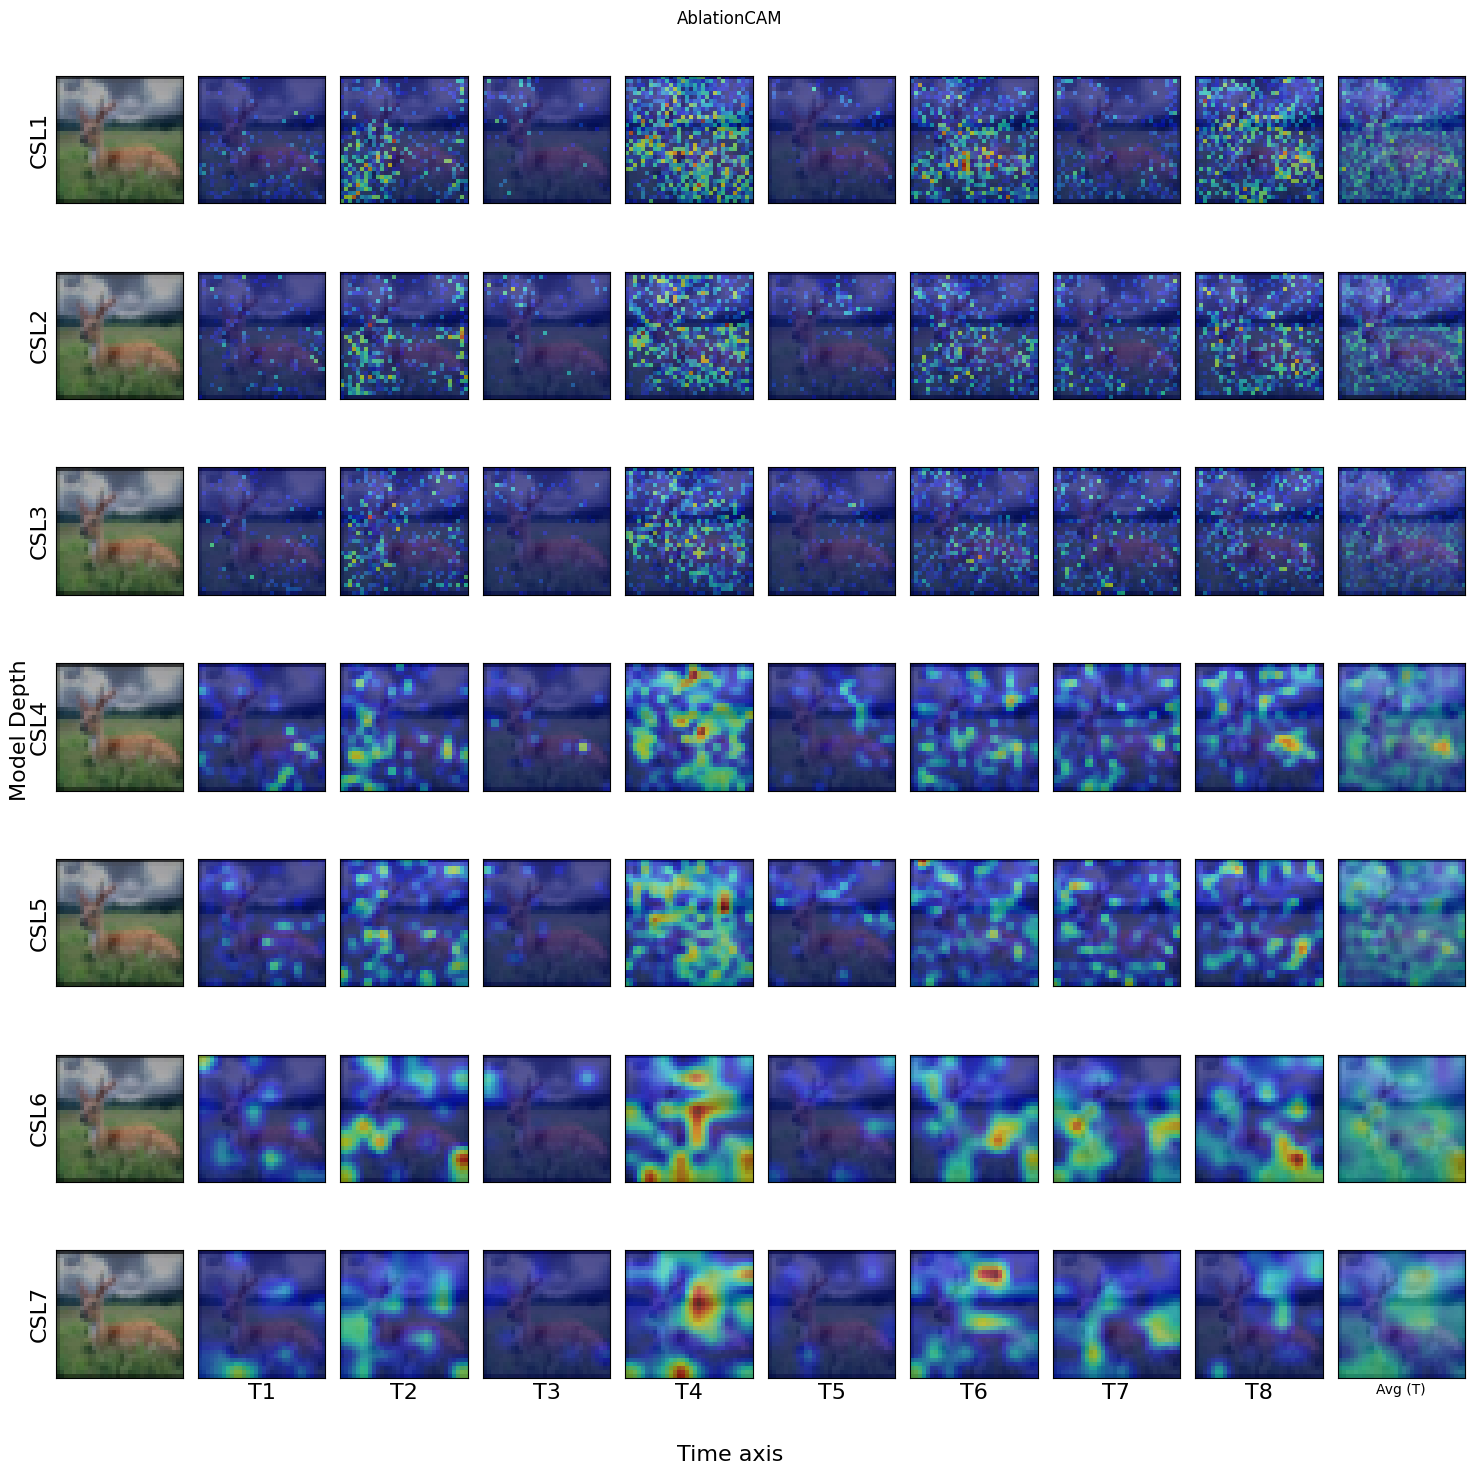

In [ ]:
fig, axs = plt.subplots(7, 10, figsize=(15,15), sharex=True, sharey=True)

input_show = inv_transform(input_tensor[0, 0:1][0])
input_show = torch.clamp(input_show, 0, 1).permute(1,2,0)
for i,ax in enumerate(axs[:, 0]):
    ax.imshow(input_show)
    ax.set_ylabel(f'CSL{i+1}', fontsize=16)

ax.set_xticks([],[])
ax.set_yticks([],[])


for li, lcams in all_CAMs.items():
    norm = lcams.max()
    for ti,ax in enumerate(axs[li, 1:9]):
        ax.imshow(input_show)
        ax.imshow(lcams[ti]/norm, alpha=0.5, cmap = 'jet', vmax=1, vmin=0)
        if li == 6:
            ax.set_xlabel(f'T{ti+1}', fontsize=16)

    # norm = lcams.mean(dim=0).max()
    axs[li, 9].imshow(input_show)
    axs[li, 9].imshow((lcams/norm).mean(dim=0), alpha=0.4, cmap = 'jet', vmax=0.5, vmin=0)
axs[6, 9].set_xlabel('Avg (T)')

fig.supxlabel('Time axis', fontsize=16)
fig.supylabel('Model Depth', fontsize=16)
fig.suptitle('AblationCAM')
fig.tight_layout()

# Get STTC

In [ ]:
import torch
import gc
import time
import numpy as np
import glob
import os
import h5py
import subprocess
import psutil
import logging

In [ ]:
torch.cuda

<module 'torch.cuda' from '/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py'>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys
sys.path.append('/content/drive/MyDrive/FORTH/Colab Codes')

from STTC_torch import *
from save_sttc_posts import *

In [ ]:
device = 'cuda:0'

path = glob.glob('/content/drive/MyDrive/FORTH/Colab Codes/models/*/spikes*perm*')[0]
path

'/content/drive/MyDrive/FORTH/Colab Codes/models/C100_T8_[KS32_FullSNN_Small_FRReg]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/spikes_all_perm1_SingleBlockShuffle(16, 0.0).h5'

In [ ]:
with h5py.File(path, 'r') as f:
    print(f['val_1'].keys())

<KeysViewHDF5 ['Test-SingleBlockShuffle(16, 0.5)', 'blurL-SingleBlockShuffle(16, 0.5)', 'blurM-SingleBlockShuffle(16, 0.5)', 'blurS-SingleBlockShuffle(16, 0.5)']>


In [ ]:
os.path.basename(path).split("spikes")[-1].replace('.h5', '')

'_all_perm1_SingleBlockShuffle(16, 0.0)'

In [ ]:
out_path = os.path.join(os.path.dirname(path), f'sttc_val_{os.path.basename(path).split("spikes_")[-1].replace('.h5', '')}.h5')
log_path = os.path.join(os.path.dirname(path), f'tracker{os.path.basename(path).split("spikes")[-1].replace('.h5', '').replace('_max', '')}.log')
logger = setup_logger(log_path)
logger.info(f'=======> {os.path.dirname(path)} > {os.path.basename(path)} <=======')
logger.info(f'-------> Saving STTC for 2048 neurons across each layer <-------')
out_path

INFO:/content/drive/MyDrive/FORTH/Colab Codes/models/C100_T8_[KS32_FullSNN_Small_FRReg]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/tracker_all_perm1_SingleBlockShuffle(16, 0.0).log:=======> /content/drive/MyDrive/FORTH/Colab Codes/models/C100_T8_[KS32_FullSNN_Small_FRReg]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD] > spikes_all_perm1_SingleBlockShuffle(16, 0.0).h5 <=======
INFO:/content/drive/MyDrive/FORTH/Colab Codes/models/C100_T8_[KS32_FullSNN_Small_FRReg]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/tracker_all_perm1_SingleBlockShuffle(16, 0.0).log:-------> Saving STTC for 2048 neurons across each layer <-------


'/content/drive/MyDrive/FORTH/Colab Codes/models/C100_T8_[KS32_FullSNN_Small_FRReg]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/sttc_val_all_perm1_SingleBlockShuffle(16, 0.0).h5'

In [ ]:
def select_neurons(spikes, layer_name):
    firing_counts = spikes.sum(axis=1)
    active = np.where(firing_counts > 10)[0]

    if "DSL" in layer_name:
        return spikes[active]

    if "CSL" in layer_name:
        keep = active[:2048]
        return spikes[keep]

    return spikes[active]

In [ ]:
def track_gpu_mem(a=None, b=None, c=None, d=None):
    pass

In [ ]:
with h5py.File(path, 'r') as spike_file, h5py.File(out_path, 'a') as f:
    for group in spike_file['val_1'].keys():
        out_group = f.require_group(group)

        logger.info(f'-----> {group}')
        print(group)
        t1 = time.time()
        for nn_layer in spike_file['val_1'][group].keys():
            if 'Down' in nn_layer:
                continue
            # if nn_layer in out_group.keys():
                # if len(out_group[nn_layer].keys())>3:
                #     continue


            layer_group = out_group.require_group(nn_layer)
            spikes_all = np.array(spike_file['val_1'][group][nn_layer])

            spikes = torch.from_numpy(spikes_all).to(device).to(torch.float32)
            # spikes = torch.from_numpy(select_neurons(spikes_all, nn_layer)).to(device).to(torch.float32)
            del spikes_all

            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()
            outputs = get_STTC_AB_posts(spikes, spikes, logger=logger, gpu_id=int(device[-1]))

            del spikes
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()

            for name, var in zip(['STTC', 'null', 'null_mean', 'null_std'], outputs):
                layer_group.create_dataset(name, data = var.cpu().numpy(), dtype='float32', compression='lzf')

            del outputs
            gc.collect()
            print(f'............> {nn_layer}')
        print(f'-----> Saved {group} : {(time.time() - t1)/60 :.2f} min')

INFO:/content/drive/MyDrive/FORTH/Colab Codes/models/C100_T8_[KS32_FullSNN_Small_FRReg]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/tracker_all_perm1_SingleBlockShuffle(16, 0.0).log:-----> Test-SingleBlockShuffle(16, 0.0)


Test-SingleBlockShuffle(16, 0.0)


INFO:/content/drive/MyDrive/FORTH/Colab Codes/models/C100_T8_[KS32_FullSNN_Small_FRReg]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/tracker_all_perm1_SingleBlockShuffle(16, 0.0).log:................. Calculated nulls : 72.8548 s
INFO:/content/drive/MyDrive/FORTH/Colab Codes/models/C100_T8_[KS32_FullSNN_Small_FRReg]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/tracker_all_perm1_SingleBlockShuffle(16, 0.0).log:>>>> GPU 0: 9.00 GB, CPU: 11.04 GB
INFO:/content/drive/MyDrive/FORTH/Colab Codes/models/C100_T8_[KS32_FullSNN_Small_FRReg]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/tracker_all_perm1_SingleBlockShuffle(16, 0.0).log:................. Calculated STTC stuff : 0.0040 s
INFO:/content/drive/MyDrive/FORTH/Colab Codes/models/C100_T8_[KS32_FullSNN_Small_FRReg]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/tracker_all_perm1_SingleBlockShuffle(16, 0.0).log:-- Total time for STTC post-hoc calcs : 74.4430 s


-- Total time : 74.4430 s
............> CSL1


INFO:/content/drive/MyDrive/FORTH/Colab Codes/models/C100_T8_[KS32_FullSNN_Small_FRReg]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/tracker_all_perm1_SingleBlockShuffle(16, 0.0).log:................. Calculated nulls : 55.0096 s
INFO:/content/drive/MyDrive/FORTH/Colab Codes/models/C100_T8_[KS32_FullSNN_Small_FRReg]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/tracker_all_perm1_SingleBlockShuffle(16, 0.0).log:>>>> GPU 0: 8.75 GB, CPU: 11.10 GB
INFO:/content/drive/MyDrive/FORTH/Colab Codes/models/C100_T8_[KS32_FullSNN_Small_FRReg]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/tracker_all_perm1_SingleBlockShuffle(16, 0.0).log:................. Calculated STTC stuff : 0.0041 s
INFO:/content/drive/MyDrive/FORTH/Colab Codes/models/C100_T8_[KS32_FullSNN_Small_FRReg]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/tracker_all_perm1_SingleBlockShuffle(16, 0.0).log:-- Total time for STTC post-hoc calcs : 85.9331 s


...

-- Total time : 4.7077 s
............> CSL7


INFO:/content/drive/MyDrive/FORTH/Colab Codes/models/C100_T8_[KS32_FullSNN_Small_FRReg]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/tracker_all_perm1_SingleBlockShuffle(16, 0.0).log:................. Calculated nulls : 0.7527 s
INFO:/content/drive/MyDrive/FORTH/Colab Codes/models/C100_T8_[KS32_FullSNN_Small_FRReg]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/tracker_all_perm1_SingleBlockShuffle(16, 0.0).log:>>>> GPU 0: 14.28 GB, CPU: 11.09 GB
INFO:/content/drive/MyDrive/FORTH/Colab Codes/models/C100_T8_[KS32_FullSNN_Small_FRReg]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/tracker_all_perm1_SingleBlockShuffle(16, 0.0).log:................. Calculated STTC stuff : 0.0010 s
INFO:/content/drive/MyDrive/FORTH/Colab Codes/models/C100_T8_[KS32_FullSNN_Small_FRReg]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/tracker_all_perm1_SingleBlockShuffle(16, 0.0).log:-- Total time for STTC post-hoc calcs : 1.2691 s


-- Total time : 1.2690 s
............> DSL1


INFO:/content/drive/MyDrive/FORTH/Colab Codes/models/C100_T8_[KS32_FullSNN_Small_FRReg]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/tracker_all_perm1_SingleBlockShuffle(16, 0.0).log:................. Calculated nulls : 0.7555 s
INFO:/content/drive/MyDrive/FORTH/Colab Codes/models/C100_T8_[KS32_FullSNN_Small_FRReg]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/tracker_all_perm1_SingleBlockShuffle(16, 0.0).log:>>>> GPU 0: 14.30 GB, CPU: 11.09 GB
INFO:/content/drive/MyDrive/FORTH/Colab Codes/models/C100_T8_[KS32_FullSNN_Small_FRReg]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/tracker_all_perm1_SingleBlockShuffle(16, 0.0).log:................. Calculated STTC stuff : 0.0009 s
INFO:/content/drive/MyDrive/FORTH/Colab Codes/models/C100_T8_[KS32_FullSNN_Small_FRReg]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/tracker_all_perm1_SingleBlockShuffle(16, 0.0).log:-- Total time for STTC post-hoc calcs : 1.2717 s


-- Total time : 1.2717 s
............> DSL2
-----> Saved blurS-SingleBlockShuffle(16, 0.0) : 17.03 min


In [ ]:
f.close()

In [ ]:
with h5py.File(out_path, 'r') as f:
    print(f.keys())

<KeysViewHDF5 ['Test-SingleBlockShuffle(16, 0.0)', 'blurL-SingleBlockShuffle(16, 0.0)', 'blurM-SingleBlockShuffle(16, 0.0)', 'blurS-SingleBlockShuffle(16, 0.0)']>


In [ ]:
import os

# path = "/content/drive/MyDrive/FORTH/Colab Codes/models/.../sttc_val_all_perm1_max.h5"
print(out_path)
size = os.path.getsize(out_path)
print(f"Size: {size/1024**3:.2f} GB")


/content/drive/MyDrive/FORTH/Colab Codes/models/C100_T8_[KS32_FullSNN_Small_FRReg]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/sttc_val_all_perm1_SingleBlockShuffle(16, 0.0).h5
Size: 14.63 GB


In [ ]:
from google.colab import files
files.download(path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
print(os.path.abspath(out_path))
print(os.path.getsize(out_path))


/content/drive/MyDrive/FORTH/Colab Codes/models/C100_T8_[KS32_FullSNN_Small_FRReg]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/sttc_val_all_perm1_SingleBlockShuffle(16, 0.0).h5
15711354596


## Inter Layer STTC

In [ ]:
inter_layers_A = ['CSL'+str(i) for i in range(1, 7)] + ['DSL1']
inter_layers_B = ['CSL'+str(i) for i in range(2, 8)] + ['DSL2']
inter_layers_A, inter_layers_B

(['CSL1', 'CSL2', 'CSL3', 'CSL4', 'CSL5', 'CSL6', 'DSL1'],
 ['CSL2', 'CSL3', 'CSL4', 'CSL5', 'CSL6', 'CSL7', 'DSL2'])

In [ ]:
out_path = os.path.join(os.path.dirname(path), f'sttc_inter_{os.path.basename(path).split("spikes_")[-1].split(".")[0]}.h5')
log_path = os.path.join(os.path.dirname(path), f'tracker{os.path.basename(path).split("spikes")[-1].split(".")[0].replace('_max', '')}.log')
logger = setup_logger(log_path)
logger.info(f'=======> {os.path.dirname(path)} > {os.path.basename(path)} <=======')
logger.info(f'-------> Saving STTC for all neurons across each inter layer <-------')


INFO:/content/drive/MyDrive/FORTH/Colab Codes/models/C100_T8_[KS32_FullSNN_Small_FRReg]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/tracker_GOOD.log:=======> /content/drive/MyDrive/FORTH/Colab Codes/models/C100_T8_[KS32_FullSNN_Small_FRReg]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD] > spikes_GOOD_max.h5 <=======
INFO:/content/drive/MyDrive/FORTH/Colab Codes/models/C100_T8_[KS32_FullSNN_Small_FRReg]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/tracker_GOOD.log:-------> Saving STTC for all neurons across each inter layer <-------


In [ ]:
out_path

'/content/drive/MyDrive/FORTH/Colab Codes/models/C100_T8_[KS32_FullSNN_Small_FRReg]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/sttc_inter_GOOD_max.h5'

In [ ]:
with h5py.File(path, 'r') as spike_file, h5py.File(out_path, 'a') as f:
    # del f['blurS']
    print(f.keys())

<KeysViewHDF5 ['Test', 'blurL']>


In [ ]:
with h5py.File(path, 'r') as spike_file, h5py.File(out_path, 'a') as f:
    for ikey in spike_file['val_1'].keys():
        if ikey in ['Test', 'blurL']:
            continue
        out_ikey = f.require_group(ikey)

        logger.info(f'-----> {ikey}')
        print(ikey)
        t1 = time.time()

        for layer_A, layer_B in zip(inter_layers_A, inter_layers_B):
            out_layer_name = f'{layer_A[:-1]}{layer_A[-1]}{layer_B[-1]}'
            out_layer = out_ikey.create_group(out_layer_name)
            print(out_layer_name, end = ' | ')

            spikes_A = torch.tensor(np.array(spike_file['val_1'][ikey][layer_A])).to(device).to(torch.float32)
            spikes_B = torch.tensor(np.array(spike_file['val_1'][ikey][layer_B])).to(device).to(torch.float32)

            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()
            outputs = get_STTC_AB_posts(spikes_A, spikes_B, logger=logger, gpu_id=int(device[-1]))

            del spikes_A, spikes_B
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()
        ####

            for name, var in zip(['STTC', 'null', 'null_mean', 'null_std'], outputs):
                out_layer.create_dataset(name, data = var.cpu().numpy(), dtype='float32', compression='lzf')

            del outputs
            gc.collect()
            logger.info(f'............> {out_layer_name}')
        logger.info(f'-----> Saved {ikey} : {(time.time() - t1)/60 :.2f} min')

INFO:/content/drive/MyDrive/FORTH/Colab Codes/models/C100_T8_[KS32_FullSNN_Small_FRReg]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/tracker_GOOD.log:-----> blurM


blurM
CSL12 | 

INFO:/content/drive/MyDrive/FORTH/Colab Codes/models/C100_T8_[KS32_FullSNN_Small_FRReg]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/tracker_GOOD.log:................. Calculated nulls : 96.2533 s
INFO:/content/drive/MyDrive/FORTH/Colab Codes/models/C100_T8_[KS32_FullSNN_Small_FRReg]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/tracker_GOOD.log:>>>> GPU 0: 7.68 GB, CPU: 11.25 GB
INFO:/content/drive/MyDrive/FORTH/Colab Codes/models/C100_T8_[KS32_FullSNN_Small_FRReg]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/tracker_GOOD.log:................. Calculated STTC stuff : 0.0063 s
INFO:/content/drive/MyDrive/FORTH/Colab Codes/models/C100_T8_[KS32_FullSNN_Small_FRReg]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/tracker_GOOD.log:-- Total time for STTC post-hoc calcs : 102.5684 s


-- Total time : 102.5684 s


INFO:/content/drive/MyDrive/FORTH/Colab Codes/models/C100_T8_[KS32_FullSNN_Small_FRReg]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/tracker_GOOD.log:............> CSL12


...

INFO:/content/drive/MyDrive/FORTH/Colab Codes/models/C100_T8_[KS32_FullSNN_Small_FRReg]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/tracker_GOOD.log:............> CSL67


DSL12 | 

INFO:/content/drive/MyDrive/FORTH/Colab Codes/models/C100_T8_[KS32_FullSNN_Small_FRReg]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/tracker_GOOD.log:................. Calculated nulls : 1.0046 s
INFO:/content/drive/MyDrive/FORTH/Colab Codes/models/C100_T8_[KS32_FullSNN_Small_FRReg]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/tracker_GOOD.log:>>>> GPU 0: 14.15 GB, CPU: 11.18 GB
INFO:/content/drive/MyDrive/FORTH/Colab Codes/models/C100_T8_[KS32_FullSNN_Small_FRReg]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/tracker_GOOD.log:................. Calculated STTC stuff : 0.0012 s
INFO:/content/drive/MyDrive/FORTH/Colab Codes/models/C100_T8_[KS32_FullSNN_Small_FRReg]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/tracker_GOOD.log:-- Total time for STTC post-hoc calcs : 1.6148 s


-- Total time : 1.6147 s


INFO:/content/drive/MyDrive/FORTH/Colab Codes/models/C100_T8_[KS32_FullSNN_Small_FRReg]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/tracker_GOOD.log:............> DSL12
INFO:/content/drive/MyDrive/FORTH/Colab Codes/models/C100_T8_[KS32_FullSNN_Small_FRReg]_bn[0.1]_tau[2.0]_batch[250]_cnf[ADD]/tracker_GOOD.log:-----> Saved blurS : 9.99 min


In [ ]:
with h5py.File(out_path, 'r') as f:
    for ikey in f.keys():
        print(ikey)
        for k,v in f[ikey].items():
            print(k, v['STTC'].shape, end=' | ')
        print()

Test
CSL12 (8192, 8192) | CSL23 (8192, 8192) | CSL34 (8192, 4096) | CSL45 (4096, 4096) | CSL56 (4096, 2048) | CSL67 (2048, 2048) | DSL12 (1024, 1024) | 
blurL
CSL12 (8192, 8192) | CSL23 (8192, 8192) | CSL34 (8192, 4096) | CSL45 (4096, 4096) | CSL56 (4096, 2048) | CSL67 (2048, 2048) | DSL12 (1024, 1024) | 
blurM
CSL12 (8192, 8192) | CSL23 (8192, 8192) | CSL34 (8192, 4096) | CSL45 (4096, 4096) | CSL56 (4096, 2048) | CSL67 (2048, 2048) | DSL12 (1024, 1024) | 
blurS
CSL12 (8192, 8192) | CSL23 (8192, 8192) | CSL34 (8192, 4096) | CSL45 (4096, 4096) | CSL56 (4096, 2048) | CSL67 (2048, 2048) | DSL12 (1024, 1024) | 
